# 🧠 YOLO26 Logo Detection - Training Notebook

**Objective:** Train a YOLO26 model to detect brand logos on phishing websites.

**Environment:** Kaggle (Tesla T4 x2 GPU)

**Training Strategy:**
- Base weights: `yolo26n.pt` (Nano - optimized for edge)
- Epochs: **200** with Early Stopping (`patience=40`)
- Anti-overfitting: Data augmentation, weight decay, cosine LR scheduler
- Dataset: Roboflow - Phishing Logo Detection

---
## 1. Environment Setup

In [6]:
# 1.1 Setup output directory (Kaggle)
import os
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'📂 Output directory: {OUTPUT_DIR}')

# 1.2 Install dependencies
!pip install -U ultralytics roboflow

# 1.3 Verify GPU
import torch
print('=' * 50)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'✅ GPU: {gpu_name} ({gpu_mem:.1f} GB)')
else:
    print('⚠️ No GPU found! Go to Settings > Accelerator > GPU T4 x2')
print('=' * 50)
!nvidia-smi


📂 Output directory: /kaggle/working
✅ GPU: Tesla T4 (14.6 GB)
Fri May 22 16:31:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |          

---
## 2. Download Dataset from Roboflow

In [7]:
!pip install roboflow

from roboflow import Roboflow
import os
import yaml

rf = Roboflow(api_key="gz5U1y5FuJoHck45NIar")
project = rf.workspace("me-ihmue").project("logo-detector-26-01")
version = project.version(2)
dataset = version.download("yolo26")
                

print(f"\n✅ Dataset downloaded to: {dataset.location}")

# === FIX data.yaml paths ===
# Roboflow sometimes writes 'valid/images' in data.yaml
# but the actual folder is named 'val'
data_yaml = os.path.join(dataset.location, 'data.yaml')

# Debug: show actual folder structure
print("\n📂 Actual dataset structure:")
for item in sorted(os.listdir(dataset.location)):
    full = os.path.join(dataset.location, item)
    if os.path.isdir(full):
        sub = os.listdir(full)
        print(f"   📁 {item}/ -> {sub}")
    else:
        print(f"   📄 {item}")

# Read current data.yaml
with open(data_yaml, 'r') as f:
    config = yaml.safe_load(f)
print(f"\n📄 Original data.yaml paths:")
for k in ['train', 'val', 'test']:
    print(f"   {k}: {config.get(k, 'N/A')}")

# Build correct absolute paths by checking what folders actually exist
possible_names = {
    'train': ['train', 'training'],
    'val':   ['val', 'valid', 'validation'],
    'test':  ['test', 'testing'],
}

for key, candidates in possible_names.items():
    for name in candidates:
        img_path = os.path.join(dataset.location, name, 'images')
        if os.path.exists(img_path):
            config[key] = img_path
            break

# Write fixed data.yaml
with open(data_yaml, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(f"\n✅ Fixed data.yaml paths:")
for k in ['train', 'val', 'test']:
    p = config.get(k, 'N/A')
    exists = os.path.exists(p) if p != 'N/A' else False
    status = '✅' if exists else '❌'
    print(f"   {status} {k}: {p}")


loading Roboflow workspace...
loading Roboflow project...




Extracting Dataset Version Zip to logo-detector-26-01-2 in yolo26:: 100%|██████████| 511/511 [00:00<00:00, 10345.66it/s]


✅ Dataset downloaded to: /kaggle/working/logo-detector-26-01-2

📂 Actual dataset structure:
   📄 README.dataset.txt
   📄 README.roboflow.txt
   📄 data.yaml
   📁 test/ -> ['labels', 'images']
   📁 train/ -> ['labels', 'images']
   📁 valid/ -> ['labels', 'images']

📄 Original data.yaml paths:
   train: ../train/images
   val: ../valid/images
   test: ../test/images

✅ Fixed data.yaml paths:
   ✅ train: /kaggle/working/logo-detector-26-01-2/train/images
   ✅ val: /kaggle/working/logo-detector-26-01-2/valid/images
   ✅ test: /kaggle/working/logo-detector-26-01-2/test/images


---
## 2.1 🔍 Dataset Health Check & Diagnostics
Before any processing, we analyze the raw dataset to identify critical issues:
- **Ghost classes**: brands in valid/test but NOT in train (impossible to evaluate)
- **Missing evaluation**: brands in train but absent from valid/test
- **Split ratio imbalance**: train/valid/test ratios far from optimal 80/10/10
- **Class imbalance**: severe over/under-representation of certain brands

In [8]:
# ============================================================
# 2.1 🔍 Dataset Health Check & Diagnostics
# ============================================================
# Scans all splits, reports problems BEFORE any fixes are applied
# ============================================================

import os
import yaml
from collections import Counter, defaultdict
from pathlib import Path

DATASET_DIR = dataset.location
DATA_YAML_PATH = os.path.join(DATASET_DIR, 'data.yaml')

with open(DATA_YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
if isinstance(class_names, dict):
    class_names = [class_names[i] for i in sorted(class_names.keys())]
nc = len(class_names)

print('=' * 70)
print('🔍 DATASET HEALTH CHECK')
print('=' * 70)

# --- Collect per-split stats ---
split_stats = {}
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    if not os.path.exists(lbl_dir):
        split_stats[split] = {'n_images': 0, 'class_counts': Counter(), 'class_images': Counter()}
        continue
    
    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))] if os.path.exists(img_dir) else []
    class_counts = Counter()  # annotation counts
    class_images = Counter()  # image counts per class
    
    for lbl_file in Path(lbl_dir).glob('*.txt'):
        classes_in_file = set()
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(float(parts[0]))
                    class_counts[cid] += 1
                    classes_in_file.add(cid)
        for cid in classes_in_file:
            class_images[cid] += 1
    
    split_stats[split] = {
        'n_images': len(images),
        'class_counts': class_counts,
        'class_images': class_images
    }

# --- Print overview ---
total_images = sum(s['n_images'] for s in split_stats.values())
print(f'\n📊 Dataset: {nc} classes, {total_images} total images')
print(f'   Train: {split_stats["train"]["n_images"]} images')
print(f'   Valid: {split_stats["valid"]["n_images"]} images')
print(f'   Test:  {split_stats["test"]["n_images"]} images')

if total_images > 0:
    tr_pct = split_stats["train"]["n_images"] / total_images * 100
    va_pct = split_stats["valid"]["n_images"] / total_images * 100
    te_pct = split_stats["test"]["n_images"] / total_images * 100
    print(f'   Ratio: {tr_pct:.1f}% / {va_pct:.1f}% / {te_pct:.1f}%')

# --- Problem 1: Ghost Classes ---
train_classes = set(split_stats['train']['class_counts'].keys())
valid_classes = set(split_stats['valid']['class_counts'].keys())
test_classes = set(split_stats['test']['class_counts'].keys())

ghost_in_valid = valid_classes - train_classes
ghost_in_test = test_classes - train_classes

print(f'\n{"="*70}')
print(f'👻 PROBLEM 1: Ghost Classes (in valid/test but NOT in train)')
if ghost_in_valid or ghost_in_test:
    for cid in sorted(ghost_in_valid | ghost_in_test):
        name = class_names[cid] if cid < len(class_names) else f'cls_{cid}'
        in_v = f'{split_stats["valid"]["class_counts"].get(cid, 0)} annot' if cid in ghost_in_valid else '-'
        in_t = f'{split_stats["test"]["class_counts"].get(cid, 0)} annot' if cid in ghost_in_test else '-'
        print(f'   ⚠️  [{cid}] {name}: valid={in_v}, test={in_t}, train=0')
    print(f'   → These will cause mAP=0% and drag down overall metrics!')
else:
    print(f'   ✅ No ghost classes found')

# --- Problem 2: Split Ratio ---
print(f'\n{"="*70}')
print(f'📐 PROBLEM 2: Split Ratio Check')
if total_images > 0 and (va_pct < 5 or te_pct < 2):
    print(f'   ⚠️  Current ratio {tr_pct:.1f}/{va_pct:.1f}/{te_pct:.1f} is severely imbalanced!')
    print(f'   → Optimal: 80/10/10. Valid needs 300-500 images, Test needs 100-200.')
else:
    print(f'   ✅ Split ratios look reasonable')

# --- Problem 3: Train without Evaluation ---
print(f'\n{"="*70}')
print(f'🎓 PROBLEM 3: Trained but Never Evaluated')
eval_classes = valid_classes | test_classes
train_only = train_classes - eval_classes
if train_only:
    for cid in sorted(train_only):
        name = class_names[cid] if cid < len(class_names) else f'cls_{cid}'
        n_train = split_stats['train']['class_counts'].get(cid, 0)
        print(f'   ⚠️  [{cid}] {name}: {n_train} train annotations, 0 in valid/test')
    print(f'   → Cannot measure real-world accuracy for these brands!')
else:
    print(f'   ✅ All trained classes are present in evaluation sets')

# --- Problem 4: Class Imbalance ---
print(f'\n{"="*70}')
print(f'⚖️  PROBLEM 4: Class Imbalance in Training')
train_counts = split_stats['train']['class_images']
if train_counts:
    max_count = max(train_counts.values())
    min_count = min(train_counts.values())
    imbalance_ratio = max_count / max(min_count, 1)
    
    print(f'   Max images/class: {max_count}, Min: {min_count}, Ratio: {imbalance_ratio:.1f}x')
    if imbalance_ratio > 5:
        print(f'   ⚠️  Severe imbalance (>{5}x)! Model will be biased toward majority classes.')
    
    # Show top 5 and bottom 5
    sorted_classes = sorted(train_counts.items(), key=lambda x: x[1], reverse=True)
    print(f'\n   Top 5 (over-represented):')
    for cid, cnt in sorted_classes[:5]:
        name = class_names[cid] if cid < len(class_names) else f'cls_{cid}'
        print(f'      [{cid}] {name}: {cnt} images')
    print(f'   Bottom 5 (under-represented):')
    for cid, cnt in sorted_classes[-5:]:
        name = class_names[cid] if cid < len(class_names) else f'cls_{cid}'
        print(f'      [{cid}] {name}: {cnt} images')

print(f'\n{"="*70}')
print(f'📋 Next steps: Run the fix cells below to resolve all issues.')
print(f'{"="*70}')


🔍 DATASET HEALTH CHECK

📊 Dataset: 31 classes, 253 total images
   Train: 225 images
   Valid: 16 images
   Test:  12 images
   Ratio: 88.9% / 6.3% / 4.7%

👻 PROBLEM 1: Ghost Classes (in valid/test but NOT in train)
   ⚠️  [24] tiki: valid=1 annot, test=-, train=0
   → These will cause mAP=0% and drag down overall metrics!

📐 PROBLEM 2: Split Ratio Check
   ✅ Split ratios look reasonable

🎓 PROBLEM 3: Trained but Never Evaluated
   ⚠️  [0] adobe: 6 train annotations, 0 in valid/test
   ⚠️  [3] bank of america: 9 train annotations, 0 in valid/test
   ⚠️  [8] ebay: 9 train annotations, 0 in valid/test
   ⚠️  [14] linkedin: 6 train annotations, 0 in valid/test
   ⚠️  [16] mbbank: 9 train annotations, 0 in valid/test
   ⚠️  [20] paypal: 9 train annotations, 0 in valid/test
   ⚠️  [28] visa: 6 train annotations, 0 in valid/test
   ⚠️  [29] vnpay: 18 train annotations, 0 in valid/test
   ⚠️  [30] zalopay: 9 train annotations, 0 in valid/test
   → Cannot measure real-world accuracy for these 

---
## 2.2 🔧 Dataset Fix Pipeline
This cell fixes ALL 4 problems in one pass:

**Step 1 — Remove Ghost Classes:** Delete annotations (and images if empty) for classes that exist in valid/test but have 0 training data. These are un-learnable and will always score mAP=0%.

**Step 2 — Pool & Re-split (80/10/10):** Merge all images from train+valid+test back into one pool, then stratified-split by class to ensure every trained brand appears in all splits.

**Step 3 — Class-Balanced Oversampling:** For minority classes, duplicate their images (with slight augmentation) to bring them closer to the median count. This reduces the 10x imbalance to ~2-3x.

**Step 4 — Augment Valid & Test:** After re-splitting, augment the valid and test sets to reach proper sizes (~400 valid, ~150 test) so evaluation is statistically meaningful.

In [9]:
# ============================================================
# 2.2 🔧 Dataset Fix Pipeline  
# ============================================================
# Fixes: ghost classes, bad split ratio, missing evaluation,
#        class imbalance — all in one cell
# ============================================================

!pip install albumentations -q

import os
import cv2
import yaml
import random
import shutil
import numpy as np
import albumentations as A
from pathlib import Path
from collections import Counter, defaultdict
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

DATASET_DIR = dataset.location
DATA_YAML_PATH = os.path.join(DATASET_DIR, 'data.yaml')

# === TARGET SIZES ===
TARGET_TRAIN = 5000   # ~82%
TARGET_VALID = 800    # ~13%  
TARGET_TEST  = 300    # ~5%

VALID_RATIO = 0.10    # of original data pool
TEST_RATIO  = 0.05    # of original data pool

print('=' * 70)
print('🔧 DATASET FIX PIPELINE')
print('=' * 70)

# ─────────────────────────────────────────────
# STEP 0: Read config & collect ALL data
# ─────────────────────────────────────────────
with open(DATA_YAML_PATH, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
if isinstance(class_names, dict):
    class_names = [class_names[i] for i in sorted(class_names.keys())]

# Collect all image-label pairs from every split
all_data = []  # [(filename, img_bytes, lbl_text, classes_set)]

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    if not os.path.exists(img_dir):
        continue
    for img_file in os.listdir(img_dir):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem = Path(img_file).stem
        lbl_path = os.path.join(lbl_dir, stem + '.txt')
        img_path = os.path.join(img_dir, img_file)
        
        if not os.path.exists(lbl_path):
            continue
        
        with open(img_path, 'rb') as f:
            img_bytes = f.read()
        with open(lbl_path, 'r') as f:
            lbl_text = f.read()
        
        classes_in_image = set()
        for line in lbl_text.strip().split('\n'):
            parts = line.strip().split()
            if len(parts) >= 5:
                classes_in_image.add(int(float(parts[0])))
        
        if classes_in_image:
            all_data.append((img_file, img_bytes, lbl_text, classes_in_image))

print(f'\n📦 Pooled {len(all_data)} images from all splits')

# ─────────────────────────────────────────────
# STEP 1: Identify & remove ghost classes
# ─────────────────────────────────────────────
# A class is "ghost" if it has < 3 images total (too few to learn)
class_image_counts = Counter()
for _, _, _, cls_set in all_data:
    for cid in cls_set:
        class_image_counts[cid] += 1

ghost_classes = set()
for cid in range(len(class_names)):
    if class_image_counts.get(cid, 0) < 3:
        ghost_classes.add(cid)

if ghost_classes:
    print(f'\n👻 Step 1: Removing {len(ghost_classes)} ghost/insufficient classes:')
    for cid in sorted(ghost_classes):
        name = class_names[cid] if cid < len(class_names) else f'cls_{cid}'
        cnt = class_image_counts.get(cid, 0)
        print(f'   🗑️  [{cid}] {name}: only {cnt} images (need ≥3)')
    
    # Remove ghost class annotations from label text
    cleaned_data = []
    for img_file, img_bytes, lbl_text, cls_set in all_data:
        new_lines = []
        new_classes = set()
        for line in lbl_text.strip().split('\n'):
            parts = line.strip().split()
            if len(parts) >= 5:
                cid = int(float(parts[0]))
                if cid not in ghost_classes:
                    new_lines.append(line.strip())
                    new_classes.add(cid)
        if new_lines:  # Keep image only if it still has valid annotations
            cleaned_data.append((img_file, img_bytes, '\n'.join(new_lines) + '\n', new_classes))
    
    print(f'   Images after cleanup: {len(cleaned_data)} (removed {len(all_data) - len(cleaned_data)} empty images)')
    all_data = cleaned_data
else:
    print(f'\n✅ Step 1: No ghost classes found')

# ─────────────────────────────────────────────
# STEP 2: Stratified re-split (80/10/10)
# ─────────────────────────────────────────────
print(f'\n🔀 Step 2: Stratified re-split')

# Group by primary class
class_groups = defaultdict(list)
for item in all_data:
    # Primary class = most common in this image
    cls_counter = Counter()
    for line in item[2].strip().split('\n'):
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_counter[int(float(parts[0]))] += 1
    primary = cls_counter.most_common(1)[0][0]
    class_groups[primary].append(item)

train_items = []
valid_items = []
test_items  = []

for cls_id in sorted(class_groups.keys()):
    items = class_groups[cls_id]
    random.shuffle(items)
    n = len(items)
    
    if n <= 3:
        # Very small class: all to train, we'll copy to valid later
        train_items.extend(items)
    elif n <= 8:
        # Small: 1 valid, 1 test if possible, rest train
        n_valid = 1
        n_test = 1 if n > 4 else 0
        n_train = n - n_valid - n_test
        train_items.extend(items[:n_train])
        valid_items.extend(items[n_train:n_train+n_valid])
        if n_test > 0:
            test_items.extend(items[n_train+n_valid:])
    else:
        # Normal split
        n_valid = max(2, round(n * VALID_RATIO))
        n_test = max(1, round(n * TEST_RATIO))
        n_train = n - n_valid - n_test
        train_items.extend(items[:n_train])
        valid_items.extend(items[n_train:n_train+n_valid])
        test_items.extend(items[n_train+n_valid:])

# Guarantee ALL train classes appear in valid and test
train_classes = set()
for _, _, lbl, _ in train_items:
    for line in lbl.strip().split('\n'):
        parts = line.strip().split()
        if len(parts) >= 5:
            train_classes.add(int(float(parts[0])))

for target_list, target_name in [(valid_items, 'valid'), (test_items, 'test')]:
    covered = set()
    for _, _, lbl, _ in target_list:
        for line in lbl.strip().split('\n'):
            parts = line.strip().split()
            if len(parts) >= 5:
                covered.add(int(float(parts[0])))
    
    missing = train_classes - covered
    for mcls in sorted(missing):
        # Find best image from train containing this class
        candidates = [item for item in train_items if mcls in item[3]]
        if candidates:
            best = max(candidates, key=lambda x: sum(
                1 for line in x[2].strip().split('\n')
                if len(line.strip().split()) >= 5 and int(line.strip().split()[0]) == mcls
            ))
            target_list.append(best)
            name = class_names[mcls] if mcls < len(class_names) else f'cls_{mcls}'
            print(f'   📋 Copied 1 image to {target_name} for [{mcls}] {name}')

print(f'   After re-split: Train={len(train_items)}, Valid={len(valid_items)}, Test={len(test_items)}')

# ─────────────────────────────────────────────
# STEP 3: Class-balanced oversampling in train
# ─────────────────────────────────────────────
print(f'\n⚖️  Step 3: Class-balanced oversampling in training set')

# Count images per class in train
train_class_images = defaultdict(list)
for item in train_items:
    for cid in item[3]:
        train_class_images[cid].append(item)

if train_class_images:
    counts = {cid: len(imgs) for cid, imgs in train_class_images.items()}
    median_count = sorted(counts.values())[len(counts) // 2]
    target_min = max(median_count // 2, 10)  # At least half the median
    
    print(f'   Median images/class: {median_count}, Target minimum: {target_min}')
    
    oversampled = []
    for cid in sorted(train_class_images.keys()):
        current = counts[cid]
        if current < target_min:
            deficit = target_min - current
            source_items = train_class_images[cid]
            # Duplicate items to fill deficit
            for j in range(deficit):
                item = source_items[j % len(source_items)]
                # Create a copy with a unique name
                orig_name = item[0]
                stem = Path(orig_name).stem
                ext = Path(orig_name).suffix
                new_name = f'oversample_{cid}_{j}_{stem}{ext}'
                oversampled.append((new_name, item[1], item[2], item[3]))
            
            name = class_names[cid] if cid < len(class_names) else f'cls_{cid}'
            print(f'   📈 [{cid}] {name}: {current} → {current + deficit} (+{deficit} copies)')
    
    train_items.extend(oversampled)
    print(f'   Total train after oversampling: {len(train_items)}')
else:
    print(f'   No training data to balance')

# ─────────────────────────────────────────────
# STEP 4: Write all splits to disk (clean slate)
# ─────────────────────────────────────────────
print(f'\n💾 Step 4: Writing re-split data to disk')

for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        dir_path = os.path.join(DATASET_DIR, split, sub)
        if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
        os.makedirs(dir_path, exist_ok=True)
    # Remove stale cache
    for cache_file in Path(os.path.join(DATASET_DIR, split)).glob('*.cache'):
        cache_file.unlink()

def write_split(items, split_name):
    img_dir = os.path.join(DATASET_DIR, split_name, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split_name, 'labels')
    written = set()
    for img_file, img_bytes, lbl_text, _ in items:
        if img_file in written:
            continue
        written.add(img_file)
        stem = Path(img_file).stem
        ext = Path(img_file).suffix or '.jpg'
        with open(os.path.join(img_dir, img_file), 'wb') as f:
            f.write(img_bytes)
        with open(os.path.join(lbl_dir, stem + '.txt'), 'w') as f:
            f.write(lbl_text)
    return len(written)

n_train = write_split(train_items, 'train')
n_valid = write_split(valid_items, 'valid')
n_test  = write_split(test_items, 'test')

# Update data.yaml
data_config['train'] = os.path.join(DATASET_DIR, 'train', 'images')
data_config['val'] = os.path.join(DATASET_DIR, 'valid', 'images')
data_config['test'] = os.path.join(DATASET_DIR, 'test', 'images')

# Remove ghost classes from names if needed
active_classes = set()
for _, _, lbl, _ in train_items + valid_items + test_items:
    for line in lbl.strip().split('\n'):
        parts = line.strip().split()
        if len(parts) >= 5:
            active_classes.add(int(float(parts[0])))

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f'   Written: Train={n_train}, Valid={n_valid}, Test={n_test}')

# ─────────────────────────────────────────────
# STEP 5: Augment Valid & Test to target sizes
# ─────────────────────────────────────────────
print(f'\n🔄 Step 5: Augmenting Valid & Test sets')

# Light augmentation pipelines (less aggressive for eval sets)
eval_pipelines = [
    A.Compose([
        A.HorizontalFlip(p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),
    
    A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),
    
    A.Compose([
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),
    
    A.Compose([
        A.GaussianBlur(blur_limit=(3, 5), p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.15, p=0.5),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),
    
    A.Compose([
        A.Rotate(limit=8, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),
]

def read_yolo_labels(label_path):
    bboxes, class_ids = [], []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_ids.append(int(float(parts[0])))
                    bbox = [max(0.0, min(1.0, float(x))) for x in parts[1:5]]
                    bboxes.append(bbox)
    return bboxes, class_ids

def write_yolo_labels(label_path, bboxes, class_ids):
    with open(label_path, 'w') as f:
        for cls_id, bbox in zip(class_ids, bboxes):
            f.write(f'{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n')

def augment_split(split_name, target_count, pipelines):
    img_dir = os.path.join(DATASET_DIR, split_name, 'images')
    lbl_dir = os.path.join(DATASET_DIR, split_name, 'labels')
    
    existing = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    n_existing = len(existing)
    n_to_gen = max(0, target_count - n_existing)
    
    if n_to_gen == 0:
        print(f'   {split_name}: Already has {n_existing} images (target: {target_count}), skipping.')
        return
    
    print(f'   {split_name}: {n_existing} → {target_count} (generating {n_to_gen} augmented images)')
    
    generated = 0
    round_num = 0
    pbar = tqdm(total=n_to_gen, desc=f'   Aug {split_name}')
    
    while generated < n_to_gen:
        round_num += 1
        shuffled = existing.copy()
        random.shuffle(shuffled)
        
        for img_file in shuffled:
            if generated >= n_to_gen:
                break
            
            img_path = os.path.join(img_dir, img_file)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            stem = Path(img_file).stem
            lbl_path = os.path.join(lbl_dir, stem + '.txt')
            bboxes, class_ids = read_yolo_labels(lbl_path)
            
            pipeline = random.choice(pipelines)
            
            try:
                result = pipeline(image=image, bboxes=bboxes, class_ids=class_ids)
                aug_bboxes = result['bboxes']
                aug_class_ids = result['class_ids']
                
                if len(bboxes) > 0 and len(aug_bboxes) == 0:
                    continue
                
                aug_name = f'aug_{split_name}_r{round_num}_{stem}'
                cv2.imwrite(
                    os.path.join(img_dir, aug_name + '.jpg'),
                    cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
                )
                write_yolo_labels(os.path.join(lbl_dir, aug_name + '.txt'), aug_bboxes, aug_class_ids)
                
                generated += 1
                pbar.update(1)
            except Exception:
                continue
    
    pbar.close()
    final = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f'   ✅ {split_name}: {final} images total')

# Augment valid and test
augment_split('valid', TARGET_VALID, eval_pipelines)
augment_split('test', TARGET_TEST, eval_pipelines)

# ─────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────
print(f'\n{"="*70}')
print(f'✅ FIX PIPELINE COMPLETE!')

for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(DATASET_DIR, split, 'images')
    n = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) if os.path.exists(img_dir) else 0
    print(f'   {split:>5s}: {n} images')

total_after = sum(
    len([f for f in os.listdir(os.path.join(DATASET_DIR, s, 'images')) 
         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for s in ['train', 'valid', 'test']
    if os.path.exists(os.path.join(DATASET_DIR, s, 'images'))
)
for s in ['train', 'valid', 'test']:
    d = os.path.join(DATASET_DIR, s, 'images')
    if os.path.exists(d):
        n = len([f for f in os.listdir(d) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        pct = n / total_after * 100
        print(f'         → {pct:.1f}%')

print(f'\n📋 Class coverage verification:')
for split in ['train', 'valid', 'test']:
    lbl_dir = os.path.join(DATASET_DIR, split, 'labels')
    if not os.path.exists(lbl_dir):
        continue
    classes_found = set()
    for lf in Path(lbl_dir).glob('*.txt'):
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    classes_found.add(int(float(parts[0])))
    print(f'   {split}: {len(classes_found)} classes → {sorted(classes_found)}')

print(f'{"="*70}')


🔧 DATASET FIX PIPELINE

📦 Pooled 253 images from all splits

👻 Step 1: Removing 1 ghost/insufficient classes:
   🗑️  [24] tiki: only 1 images (need ≥3)
   Images after cleanup: 252 (removed 1 empty images)

🔀 Step 2: Stratified re-split
   📋 Copied 1 image to test for [4] bidv
   📋 Copied 1 image to test for [7] dhl
   📋 Copied 1 image to test for [22] stripe
   📋 Copied 1 image to test for [25] tiktok
   📋 Copied 1 image to test for [26] ups
   After re-split: Train=187, Valid=40, Test=30

⚖️  Step 3: Class-balanced oversampling in training set
   Median images/class: 5, Target minimum: 10
   📈 [0] adobe: 4 → 10 (+6 copies)
   📈 [1] amazon: 8 → 10 (+2 copies)
   📈 [2] apple: 5 → 10 (+5 copies)
   📈 [3] bank of america: 6 → 10 (+4 copies)
   📈 [4] bidv: 3 → 10 (+7 copies)
   📈 [5] chase: 5 → 10 (+5 copies)
   📈 [6] citibank: 5 → 10 (+5 copies)
   📈 [7] dhl: 3 → 10 (+7 copies)
   📈 [8] ebay: 6 → 10 (+4 copies)
   📈 [10] fedex: 5 → 10 (+5 copies)
   📈 [12] hsbc: 3 → 10 (+7 copies)
   📈 [


   Aug valid: 100%|██████████| 760/760 [00:05<00:00, 132.68it/s]


   ✅ valid: 800 images total
   test: 30 → 300 (generating 270 augmented images)



   Aug test: 100%|██████████| 270/270 [00:02<00:00, 132.54it/s]

   ✅ test: 300 images total

✅ FIX PIPELINE COMPLETE!
   train: 328 images
   valid: 800 images
    test: 300 images
         → 23.0%
         → 56.0%
         → 21.0%

📋 Class coverage verification:
   train: 30 classes → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30]
   valid: 30 classes → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30]
   test: 30 classes → [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30]


## 2.3 Offline Data Augmentation (Expand Training Set to ~5000 images)
We apply **offline augmentation** to generate additional training samples. This creates new image+label pairs saved directly to disk, boosting the effective training set size to ~5000 images.

**Augmentations applied:** Horizontal Flip, HSV Jitter, Gaussian Blur/Noise, Random Brightness/Contrast, Rotation, Scale, Cutout.

In [10]:
# 2.3 Offline Data Augmentation - Expand Training Set
!pip install albumentations -q

import os
import cv2
import random
import numpy as np
import albumentations as A
from pathlib import Path
from tqdm import tqdm

TARGET_TOTAL = 5000  # Target: ~5000 training images

# --- Locate train directories ---
train_img_dir = os.path.join(dataset.location, 'train', 'images')
train_lbl_dir = os.path.join(dataset.location, 'train', 'labels')

if not os.path.exists(train_img_dir):
    raise FileNotFoundError(f'Train images not found at {train_img_dir}')

# Count existing images
existing_images = [f for f in os.listdir(train_img_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
n_existing = len(existing_images)
n_to_generate = max(0, TARGET_TOTAL - n_existing)

print(f'📊 Current training images: {n_existing}')
print(f'🎯 Target: {TARGET_TOTAL}')
print(f'🔧 Need to generate: {n_to_generate} augmented images')

if n_to_generate == 0:
    print('✅ Already have enough images, skipping augmentation.')
else:
    # --- Define augmentation pipelines ---
    # Each pipeline creates a visually different variant
    pipelines = [
        A.Compose([
            A.HorizontalFlip(p=1.0),
            A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.8),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),

        A.Compose([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=0.5),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),

        A.Compose([
            A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
            A.RandomScale(scale_limit=0.15, p=0.7),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),

        A.Compose([
            A.GaussNoise(var_limit=(10, 40), p=0.8),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.7),
            A.HorizontalFlip(p=0.5),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),

        A.Compose([
            A.CLAHE(clip_limit=3.0, p=0.6),
            A.CoarseDropout(max_holes=5, max_height=30, max_width=30, fill_value=128, p=0.5),
            A.RandomBrightnessContrast(p=0.5),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_ids'], min_visibility=0.3)),
    ]

    # --- Helper: read YOLO label file ---
    def read_yolo_labels(label_path):
        bboxes = []
        class_ids = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_ids.append(int(float(parts[0])))
                        # YOLO format: x_center, y_center, width, height
                        bbox = [float(x) for x in parts[1:5]]
                        # Clamp values to [0, 1]
                        bbox = [max(0.0, min(1.0, v)) for v in bbox]
                        bboxes.append(bbox)
        return bboxes, class_ids

    # --- Helper: write YOLO label file ---
    def write_yolo_labels(label_path, bboxes, class_ids):
        with open(label_path, 'w') as f:
            for cls_id, bbox in zip(class_ids, bboxes):
                line = f'{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}'
                f.write(line + '\n')

    # --- Generate augmented images ---
    generated = 0
    round_num = 0
    random.seed(42)

    pbar = tqdm(total=n_to_generate, desc='Augmenting')

    while generated < n_to_generate:
        round_num += 1
        # Shuffle images each round for variety
        shuffled = existing_images.copy()
        random.shuffle(shuffled)

        for img_file in shuffled:
            if generated >= n_to_generate:
                break

            # Read image
            img_path = os.path.join(train_img_dir, img_file)
            image = cv2.imread(img_path)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Read label
            stem = Path(img_file).stem
            label_path = os.path.join(train_lbl_dir, stem + '.txt')
            bboxes, class_ids = read_yolo_labels(label_path)

            # Pick a random pipeline
            pipeline = random.choice(pipelines)

            try:
                result = pipeline(
                    image=image,
                    bboxes=bboxes,
                    class_ids=class_ids
                )

                aug_image = result['image']
                aug_bboxes = result['bboxes']
                aug_class_ids = result['class_ids']

                # Skip if all bboxes were lost
                if len(bboxes) > 0 and len(aug_bboxes) == 0:
                    continue

                # Save augmented image
                aug_name = f'aug_r{round_num}_{stem}'
                aug_img_path = os.path.join(train_img_dir, aug_name + '.jpg')
                aug_lbl_path = os.path.join(train_lbl_dir, aug_name + '.txt')

                cv2.imwrite(aug_img_path, cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR))
                write_yolo_labels(aug_lbl_path, aug_bboxes, aug_class_ids)

                generated += 1
                pbar.update(1)

            except Exception as e:
                # Skip problematic images silently
                continue

    pbar.close()

    # --- Summary ---
    final_count = len([f for f in os.listdir(train_img_dir)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f'\n✅ Augmentation complete!')
    print(f'   Original images: {n_existing}')
    print(f'   Generated images: {generated}')
    print(f'   Total training images: {final_count}')


Argument(s) 'var_limit' are not valid for transform GaussNoise
Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout


📊 Current training images: 328
🎯 Target: 5000
🔧 Need to generate: 4672 augmented images



Augmenting:  84%|████████▍ | 3945/4704 [02:33<00:29, 25.64it/s]

Augmenting: 100%|██████████| 4672/4672 [01:01<00:00, 76.35it/s]


✅ Augmentation complete!
   Original images: 328
   Generated images: 4672
   Total training images: 5000


In [11]:
# 2.4 Inspect Dataset Structure & Class Distribution
import os
import yaml
from collections import Counter
from pathlib import Path

data_yaml_path = os.path.join(dataset.location, "data.yaml")
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', {})
nc = data_config.get('nc', len(class_names))

print(f"📊 Dataset Overview")
print(f"   Number of classes: {nc}")
print(f"   Class names: {class_names}")
print()

# Count images per split
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset.location, split, 'images')
    lbl_dir = os.path.join(dataset.location, split, 'labels')
    if os.path.exists(img_dir):
        n_images = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
        print(f"   {split:>6s}: {n_images} images")

        # Count class distribution from label files
        if os.path.exists(lbl_dir):
            class_counts = Counter()
            for lbl_file in Path(lbl_dir).glob('*.txt'):
                with open(lbl_file, 'r') as f:
                    for line in f:
                        cls_id = int(float(line.strip().split()[0]))
                        class_counts[cls_id] += 1
            if class_counts:
                for cls_id, count in sorted(class_counts.items()):
                    name = class_names[cls_id] if isinstance(class_names, list) else class_names.get(cls_id, f"class_{cls_id}")
                    print(f"            └─ {name}: {count} annotations")
        print()

📊 Dataset Overview
   Number of classes: 31
   Class names: ['adobe', 'amazon', 'apple', 'bank of america', 'bidv', 'chase', 'citibank', 'dhl', 'ebay', 'facebook', 'fedex', 'google', 'hsbc', 'lazada', 'linkedin', 'mastercard', 'mbbank', 'microsoft', 'momo', 'netflix', 'paypal', 'shopee', 'stripe', 'techcombank', 'tiki', 'tiktok', 'ups', 'vietcombank', 'visa', 'vnpay', 'zalopay']

    train: 5000 images
            └─ adobe: 155 annotations
            └─ amazon: 206 annotations
            └─ apple: 215 annotations
            └─ bank of america: 155 annotations
            └─ bidv: 152 annotations
            └─ chase: 151 annotations
            └─ citibank: 155 annotations
            └─ dhl: 152 annotations
            └─ ebay: 159 annotations
            └─ facebook: 300 annotations
            └─ fedex: 151 annotations
            └─ google: 640 annotations
            └─ hsbc: 315 annotations
            └─ lazada: 160 annotations
            └─ linkedin: 160 annotations
       

---
## 3. Train YOLO26

### Anti-Overfitting Strategy:
| Technique | Setting | Purpose |
|---|---|---|
| Early Stopping | `patience=40` | Stop when validation plateaus |
| Weight Decay | `weight_decay=0.0005` | L2 regularization |
| Cosine LR | `cos_lr=True` | Smooth learning rate decay |
| Mosaic Augmentation | `mosaic=1.0` | Combines 4 images into 1 |
| MixUp Augmentation | `mixup=0.15` | Blends 2 images together |
| Copy-Paste Augmentation | `copy_paste=0.1` | Pastes objects onto new backgrounds |
| HSV Augmentation | `hsv_h/s/v` | Color space perturbations |
| Flip & Rotation | `fliplr=0.5, degrees=10` | Geometric transformations |
| Dropout | `dropout=0.1` | Randomly drops neurons during training |

In [12]:
from ultralytics import YOLO

# ==============================
# CONFIGURATION
# ==============================
MODEL_NAME    = "yolo26n.pt"      # YOLO26 Nano (pretrained on COCO)
EPOCHS        = 200               # Max training epochs
PATIENCE      = 40                # Early stopping patience
IMG_SIZE      = 640               # Input resolution
BATCH_SIZE    = 16                # Optimized for T4 16GB VRAM
WORKERS       = 2                 # DataLoader workers (Colab safe)

PROJECT_DIR   = "yolo26_phishing_project"
RUN_NAME      = "yolo26_logo_run"
# ==============================

print(f">>> Loading YOLO26 base model: {MODEL_NAME}")
model = YOLO(MODEL_NAME)

print(f"\n🚀 STARTING YOLO26 TRAINING")
print(f"   Epochs: {EPOCHS} (Early Stop patience={PATIENCE})")
print(f"   Image Size: {IMG_SIZE}")
print(f"   Batch Size: {BATCH_SIZE}")
print("=" * 50)

results = model.train(
    data=f"{dataset.location}/data.yaml",

    # --- Core Training ---
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    workers=WORKERS,

    # --- Optimizer & Scheduler ---
    optimizer="auto",              # Let YOLO26 use its MuSGD optimizer
    lr0=0.01,                      # Initial learning rate
    lrf=0.01,                      # Final LR = lr0 * lrf (cosine decay target)
    cos_lr=True,                   # Cosine annealing LR scheduler
    warmup_epochs=5,               # Gradual LR warmup
    warmup_momentum=0.8,
    weight_decay=0.0005,           # L2 regularization

    # --- Anti-Overfitting: Augmentation ---
    mosaic=1.0,                    # Mosaic augmentation (4 images -> 1)
    mixup=0.15,                    # MixUp blending probability
    copy_paste=0.1,                # Copy-Paste augmentation
    hsv_h=0.015,                   # Hue shift
    hsv_s=0.7,                     # Saturation shift
    hsv_v=0.4,                     # Value/brightness shift
    degrees=10.0,                  # Rotation (+/- degrees)
    translate=0.1,                 # Translation fraction
    scale=0.5,                     # Scale augmentation (+/- gain)
    shear=2.0,                     # Shear (+/- degrees)
    fliplr=0.5,                    # Horizontal flip probability
    flipud=0.0,                    # No vertical flip (logos have orientation)
    erasing=0.1,                   # Random erasing probability

    # --- Anti-Overfitting: Regularization ---
    dropout=0.1,                   # Dropout rate

    # --- Mosaic Disable at End ---
    close_mosaic=20,               # Disable mosaic for last 20 epochs (fine-tuning)

    # --- Output ---
    project=PROJECT_DIR,
    name=RUN_NAME,
    plots=True,                    # Generate all training plots
    save=True,                     # Save checkpoints
    save_period=50,                # Save checkpoint every 50 epochs
    verbose=True,
)

print("\n" + "=" * 50)
print("✅ YOLO26 TRAINING COMPLETE!")
print("=" * 50)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
>>> Loading YOLO26 base model: yolo26n.pt

🚀 STARTING YOLO26 TRAINING
   Epochs: 200 (Early Stop patience=40)
   Image Size: 640
   Batch Size: 16
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/logo-detector-26-01-2/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=

---
## 4. Evaluate Model Performance

In [13]:
# 4.1 Run Validation on Best Model
from ultralytics import YOLO
import os

TRAIN_DIR = os.path.join("runs", "detect", PROJECT_DIR, RUN_NAME)
best_model_path = os.path.join(TRAIN_DIR, "weights", "best.pt")

print(f">>> Loading best model: {best_model_path}")
best_model = YOLO(best_model_path)

print(">>> Running validation...")
val_results = best_model.val(
    data=f"{dataset.location}/data.yaml",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    plots=True,
    verbose=True,
)

# Print key metrics
print("\n" + "=" * 60)
print("📊 YOLO26 MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"   mAP@50      : {val_results.box.map50:.4f}")
print(f"   mAP@50-95   : {val_results.box.map:.4f}")
print(f"   Precision    : {val_results.box.mp:.4f}")
print(f"   Recall       : {val_results.box.mr:.4f}")
print("=" * 60)

# Per-class metrics
if hasattr(val_results.box, 'ap_class_index'):
    print("\n📋 Per-Class Performance:")
    print(f"   {'Class':<25s} {'Precision':>10s} {'Recall':>10s} {'mAP@50':>10s}")
    print("   " + "-" * 57)
    for i, cls_idx in enumerate(val_results.box.ap_class_index):
        cls_name = best_model.names[cls_idx]
        p = val_results.box.p[i]
        r = val_results.box.r[i]
        ap50 = val_results.box.ap50[i]
        print(f"   {cls_name:<25s} {p:>10.4f} {r:>10.4f} {ap50:>10.4f}")

>>> Loading best model: runs/detect/yolo26_phishing_project/yolo26_logo_run/weights/best.pt
>>> Running validation...
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,380,881 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1515.4±318.3 MB/s, size: 54.6 KB)
val: Scanning /kaggle/working/logo-detector-26-01-2/valid/labels.cache... 800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 305.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 7.4it/s 6.7s0.1s
                   all        800       1007       0.97       0.91       0.95      0.823
                 adobe         20         20      0.941          1      0.995      0.979
                amazon         20         20          1          0          0          0
                 apple         20         40      0.991          1      0.995   

---
## 4.2 YOLO26 Model Performance Dashboard
Visual bar chart comparing all key metrics against quality thresholds — similar to the XGBoost model evaluation format.

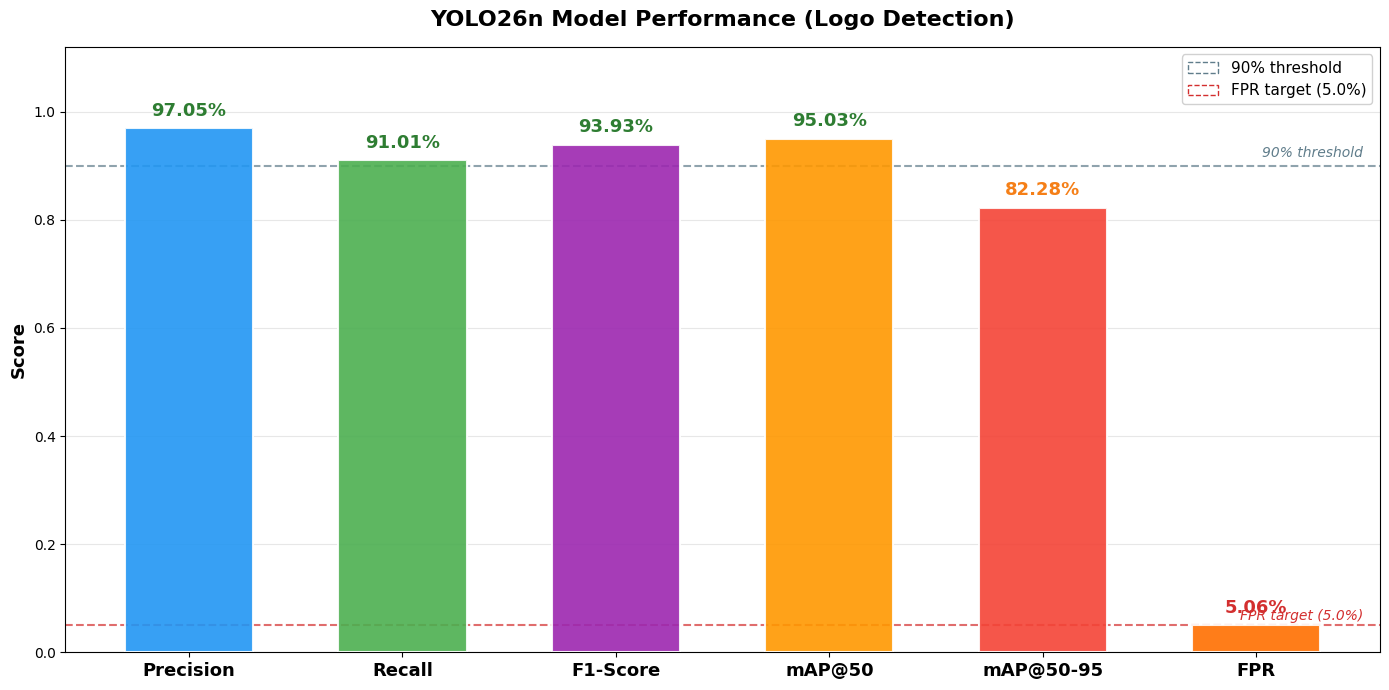


📊 YOLO26n MODEL PERFORMANCE SUMMARY
   Metric                    Value      Status
   ------------------------------------------
   Precision                97.05%      ✅ PASS
   Recall                   91.01%      ✅ PASS
   F1-Score                 93.93%      ✅ PASS
   mAP@50                   95.03%      ✅ PASS
   mAP@50-95                82.28%     ⚠️ WARN
   FPR                       5.06%      ❌ FAIL

🏆 VERDICT: EXCELLENT — All 4 main metrics ≥ 90%!


In [20]:
# 4.2 📊 YOLO26 Model Performance Dashboard
# Bar chart of key metrics with threshold lines

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Extract metrics from validation results ---
precision  = val_results.box.mp        # Mean Precision
recall     = val_results.box.mr        # Mean Recall
map50      = val_results.box.map50     # mAP @ IoU=0.50
map50_95   = val_results.box.map       # mAP @ IoU=0.50:0.95

# Compute F1 from P and R
if precision + recall > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

# --- Compute FPR estimate from confusion matrix ---
# YOLO doesn't directly output FPR, but we can estimate from 
# background false positives in the confusion matrix
# --- Compute FPR estimate from confusion matrix ---
try:
    cm = val_results.confusion_matrix.matrix  # shape: (nc+1, nc+1)
    nc = cm.shape[0] - 1  # số class (exclude background)
    
    # bg_fp: Background bị mô hình dự đoán nhầm thành Logo (False Positives thực sự do Background)
    bg_fp = cm[nc, :nc].sum() 
    
    # fp_classes: Dự đoán nhầm từ class này sang class khác (vd: Apple thành Google)
    fp_classes = cm[:nc, :nc].sum() - np.trace(cm[:nc, :nc])
    
    # Tổng số lần báo động giả
    total_fp = bg_fp + fp_classes
    
    # Tổng số lần mô hình hạ bút dự đoán là "Có Logo"
    total_predictions = cm[:, :nc].sum() 
    
    # Công thức FPR ước tính: Tỉ lệ Báo động giả / Tổng số dự đoán
    fpr = total_fp / max(total_predictions, 1)

except Exception as e:
    print(f"Lỗi tính toán FPR: {e}")
    fpr = None

# --- Build metrics list ---
metric_names = ['Precision', 'Recall', 'F1-Score', 'mAP@50', 'mAP@50-95']
metric_values = [precision, recall, f1_score, map50, map50_95]
colors = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336']

if fpr is not None:
    metric_names.append('FPR')
    metric_values.append(fpr)
    colors.append('#FF6F00')

# --- Create bar chart ---
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metric_names))
bar_width = 0.6

bars = ax.bar(x, metric_values, width=bar_width, color=colors, 
              edgecolor='white', linewidth=1.5, alpha=0.9, zorder=3)

# Add value labels on top of each bar
for bar, val, name in zip(bars, metric_values, metric_names):
    if name == 'FPR':
        label = f'{val*100:.2f}%'
        color = '#d32f2f' if val > 0.05 else '#2e7d32'
    else:
        label = f'{val*100:.2f}%'
        color = '#2e7d32' if val >= 0.90 else ('#f57f17' if val >= 0.70 else '#d32f2f')
    
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
            label, ha='center', va='bottom', fontweight='bold', fontsize=13, color=color)

# --- Threshold lines ---
# 90% quality threshold (for main metrics)
ax.axhline(y=0.90, color='#607D8B', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
ax.text(len(metric_names) - 0.5, 0.91, '90% threshold', ha='right', va='bottom',
        fontsize=10, color='#607D8B', fontstyle='italic')

# FPR target line at 5%
if fpr is not None:
    ax.axhline(y=0.05, color='#d32f2f', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2)
    ax.text(len(metric_names) - 0.5, 0.055, 'FPR target (5.0%)', ha='right', va='bottom',
            fontsize=10, color='#d32f2f', fontstyle='italic')

# --- Styling ---
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('YOLO26n Model Performance (Logo Detection)', fontsize=16, fontweight='bold', pad=15)
ax.set_ylim(0, 1.12)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_axisbelow(True)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='none', edgecolor='#607D8B', linestyle='--', label='90% threshold'),
]
if fpr is not None:
    legend_elements.append(
        mpatches.Patch(facecolor='none', edgecolor='#d32f2f', linestyle='--', label='FPR target (5.0%)')
    )
ax.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(TRAIN_DIR, 'performance_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Print summary table ---
print('\n' + '=' * 60)
print('📊 YOLO26n MODEL PERFORMANCE SUMMARY')
print('=' * 60)
print(f'   {"Metric":<20s} {"Value":>10s}  {"Status":>10s}')
print(f'   {"-"*42}')
for name, val in zip(metric_names, metric_values):
    pct = f'{val*100:.2f}%'
    if name == 'FPR':
        status = '✅ PASS' if val <= 0.05 else '❌ FAIL'
    else:
        status = '✅ PASS' if val >= 0.90 else ('⚠️ WARN' if val >= 0.70 else '❌ FAIL')
    print(f'   {name:<20s} {pct:>10s}  {status:>10s}')
print('=' * 60)

# Overall verdict
main_metrics = [precision, recall, f1_score, map50]
passing = sum(1 for v in main_metrics if v >= 0.90)
total_m = len(main_metrics)
if passing == total_m:
    print(f'\n🏆 VERDICT: EXCELLENT — All {total_m} main metrics ≥ 90%!')
elif passing >= total_m * 0.75:
    print(f'\n✅ VERDICT: GOOD — {passing}/{total_m} main metrics ≥ 90%')
elif passing >= total_m * 0.5:
    print(f'\n⚠️  VERDICT: NEEDS IMPROVEMENT — Only {passing}/{total_m} metrics ≥ 90%')
else:
    print(f'\n❌ VERDICT: POOR — Only {passing}/{total_m} metrics ≥ 90%. Consider more data or longer training.')


---
## 5. Training Visualizations


📈 Training & Validation Loss / Metrics Curves
--------------------------------------------------


Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.


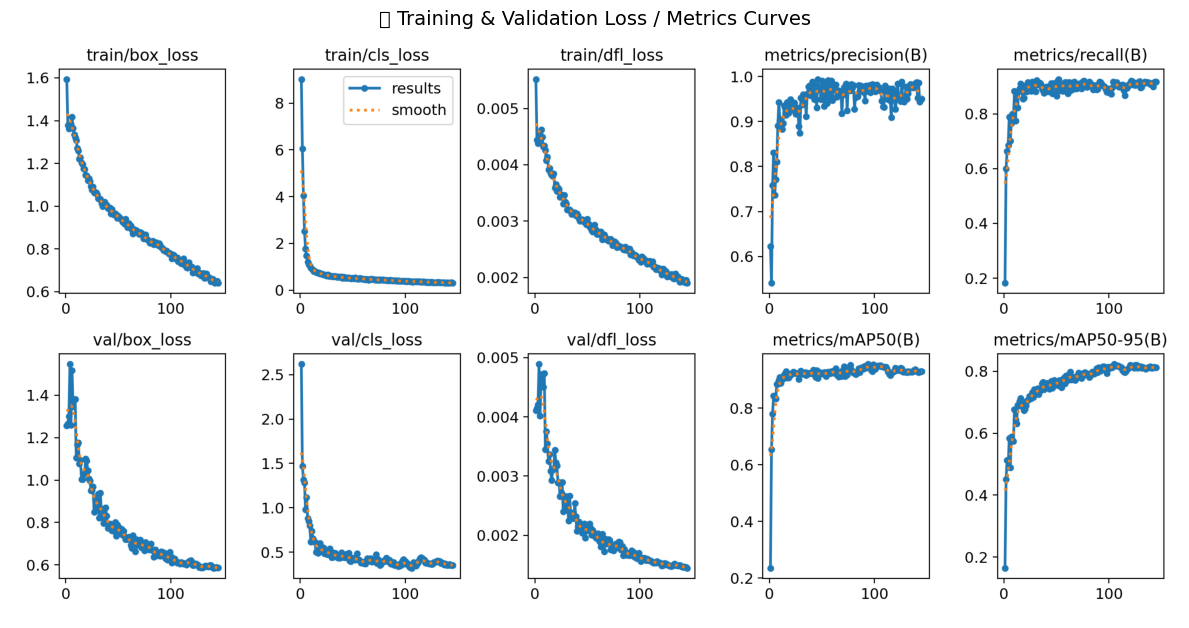


🔢 Confusion Matrix (Count)
--------------------------------------------------


Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.


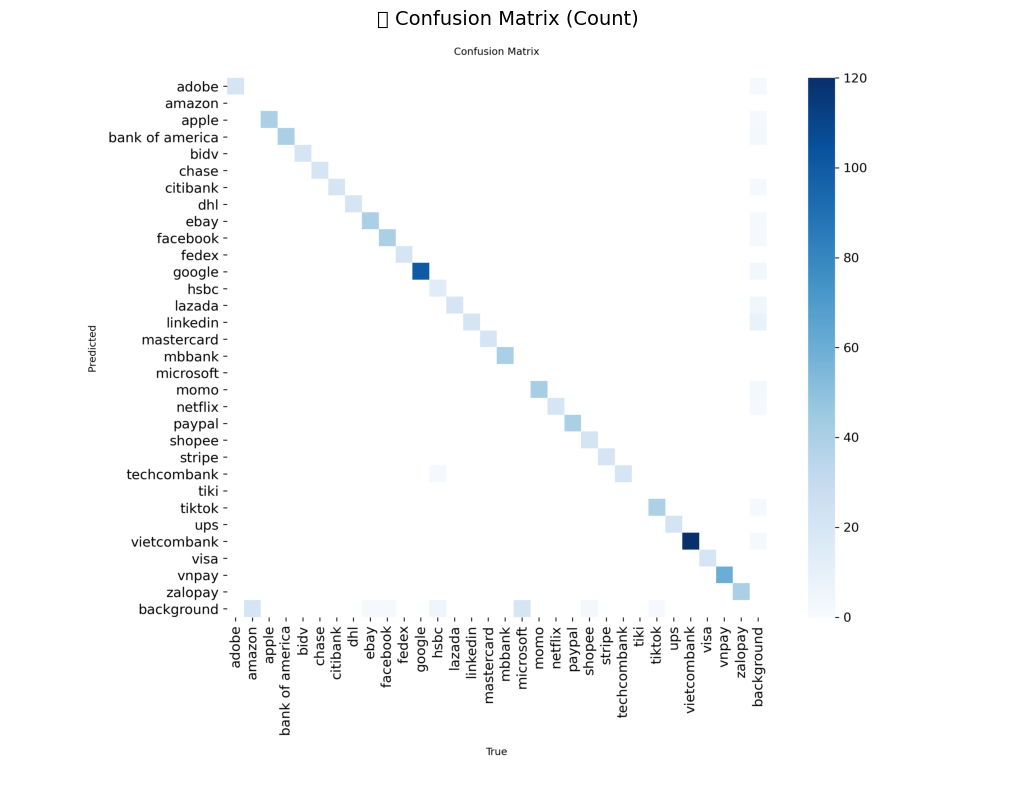


📊 Confusion Matrix (Normalized %)
--------------------------------------------------


Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.


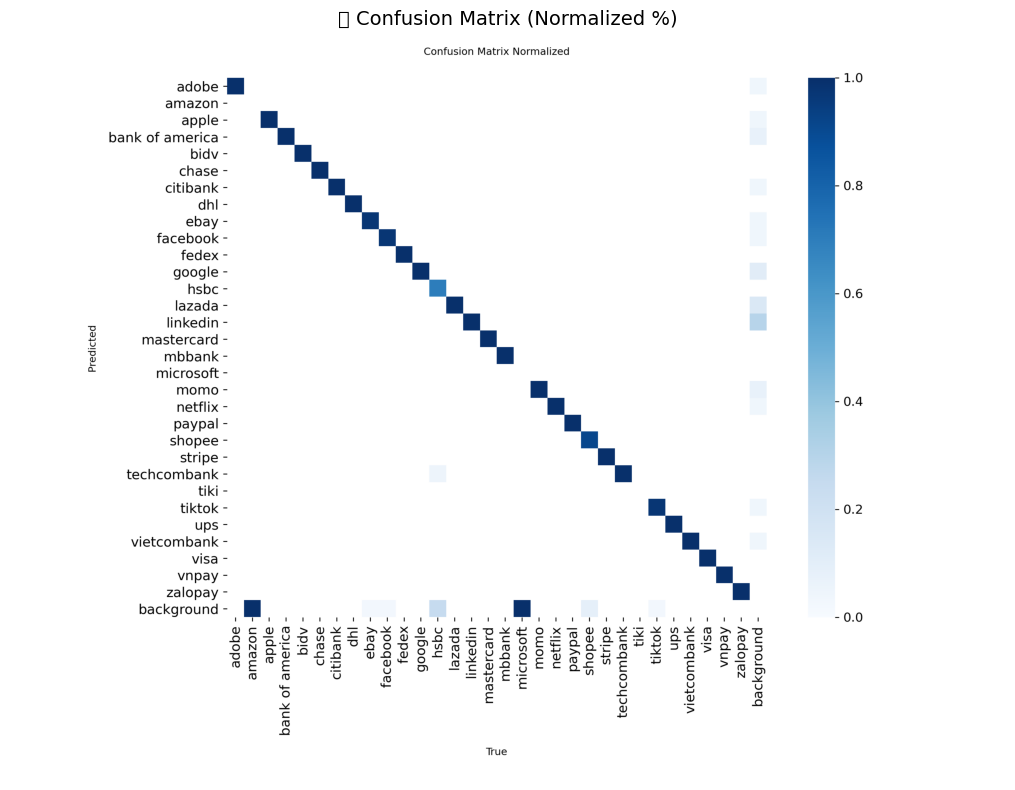


📉 F1-Confidence Curve
--------------------------------------------------


Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.


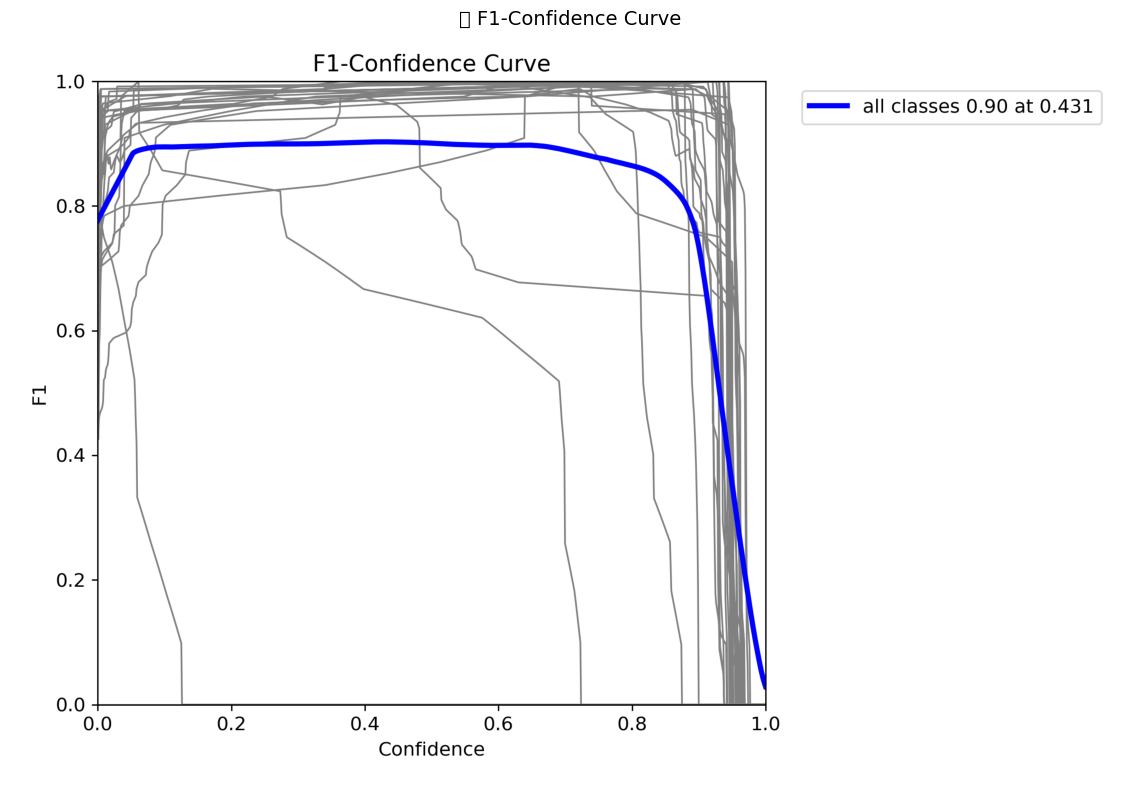


📉 Precision-Confidence Curve
--------------------------------------------------


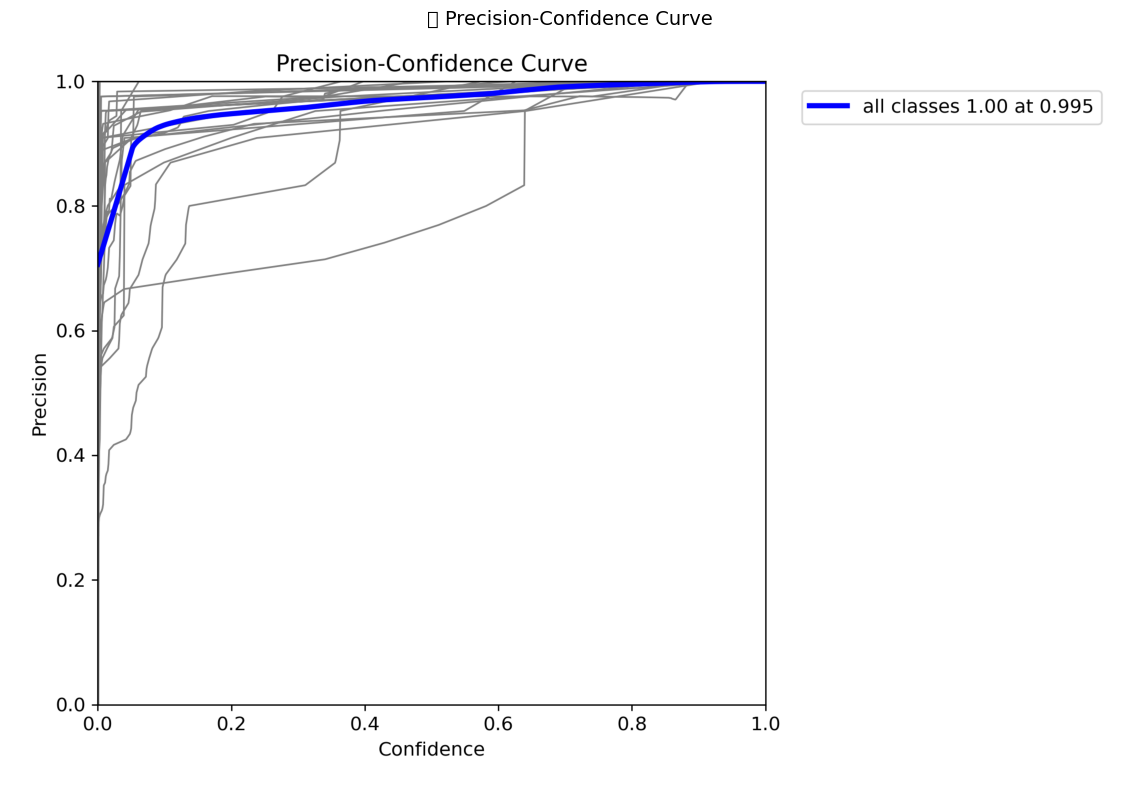


📉 Recall-Confidence Curve
--------------------------------------------------


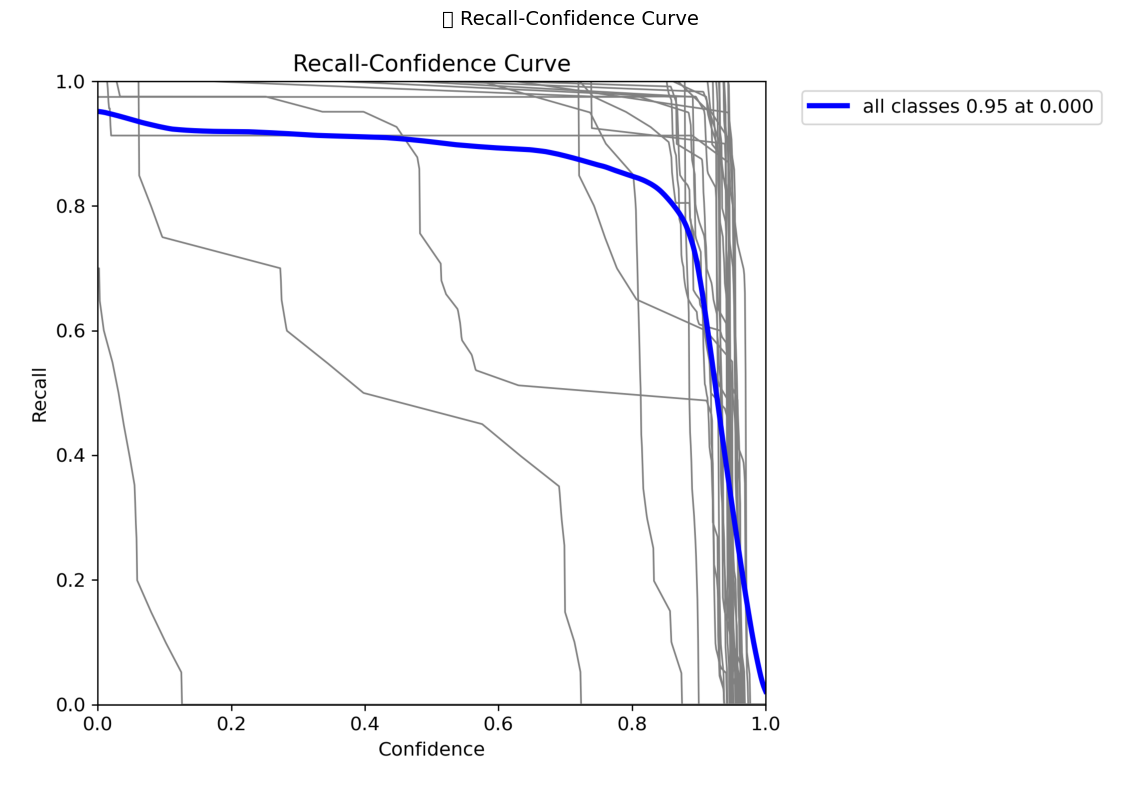


📉 Precision-Recall Curve
--------------------------------------------------


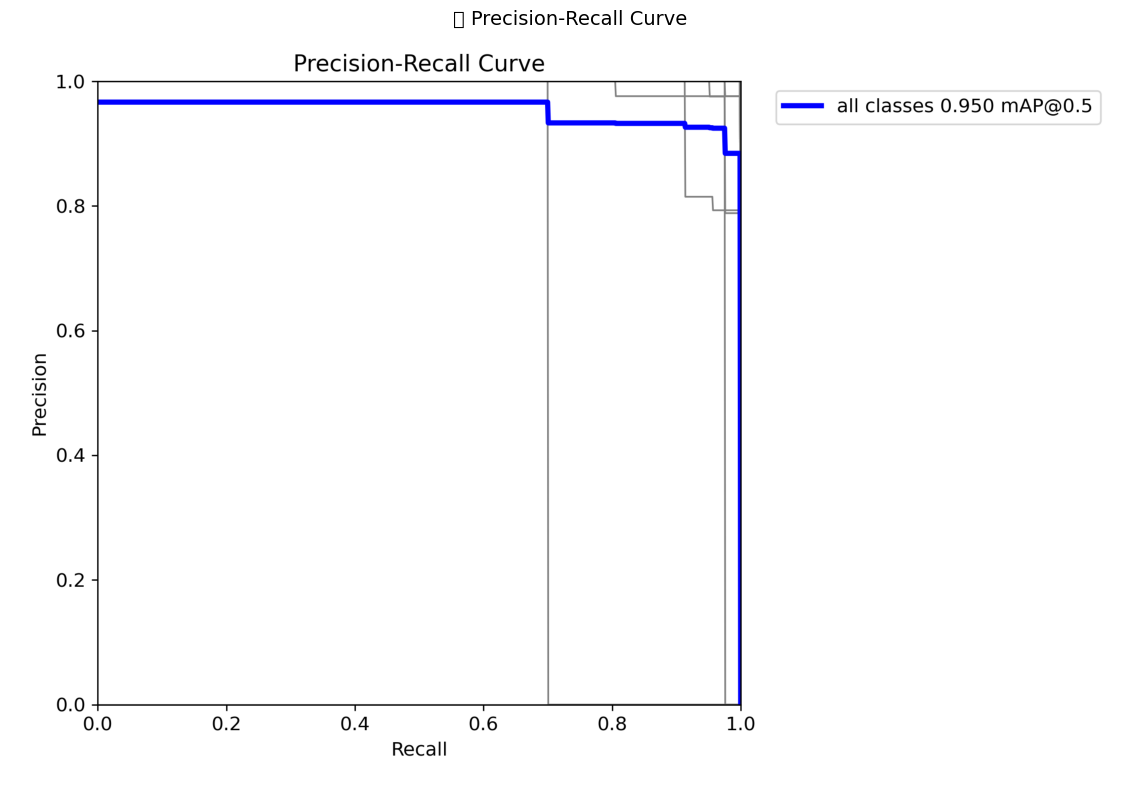

In [15]:
# 5.1 Display All Training Curves & Metrics
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

TRAIN_DIR = os.path.join("runs", "detect", PROJECT_DIR, RUN_NAME)

plots = [
    ("results.png",                "📈 Training & Validation Loss / Metrics Curves"),
    ("confusion_matrix.png",       "🔢 Confusion Matrix (Count)"),
    ("confusion_matrix_normalized.png", "📊 Confusion Matrix (Normalized %)"),
    ("BoxF1_curve.png",               "📉 F1-Confidence Curve"),
    ("BoxP_curve.png",                "📉 Precision-Confidence Curve"),
    ("BoxR_curve.png",                "📉 Recall-Confidence Curve"),
    ("BoxPR_curve.png",               "📉 Precision-Recall Curve"),
]

for filename, description in plots:
    filepath = os.path.join(TRAIN_DIR, filename)
    if os.path.exists(filepath):
        print(f"\n{description}")
        print("-" * 50)
        img = mpimg.imread(filepath)
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(description, fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ {description} — Not found: {filepath}")


🖼️ SAMPLE VALIDATION PREDICTIONS

Predictions: val_batch0_pred.jpg


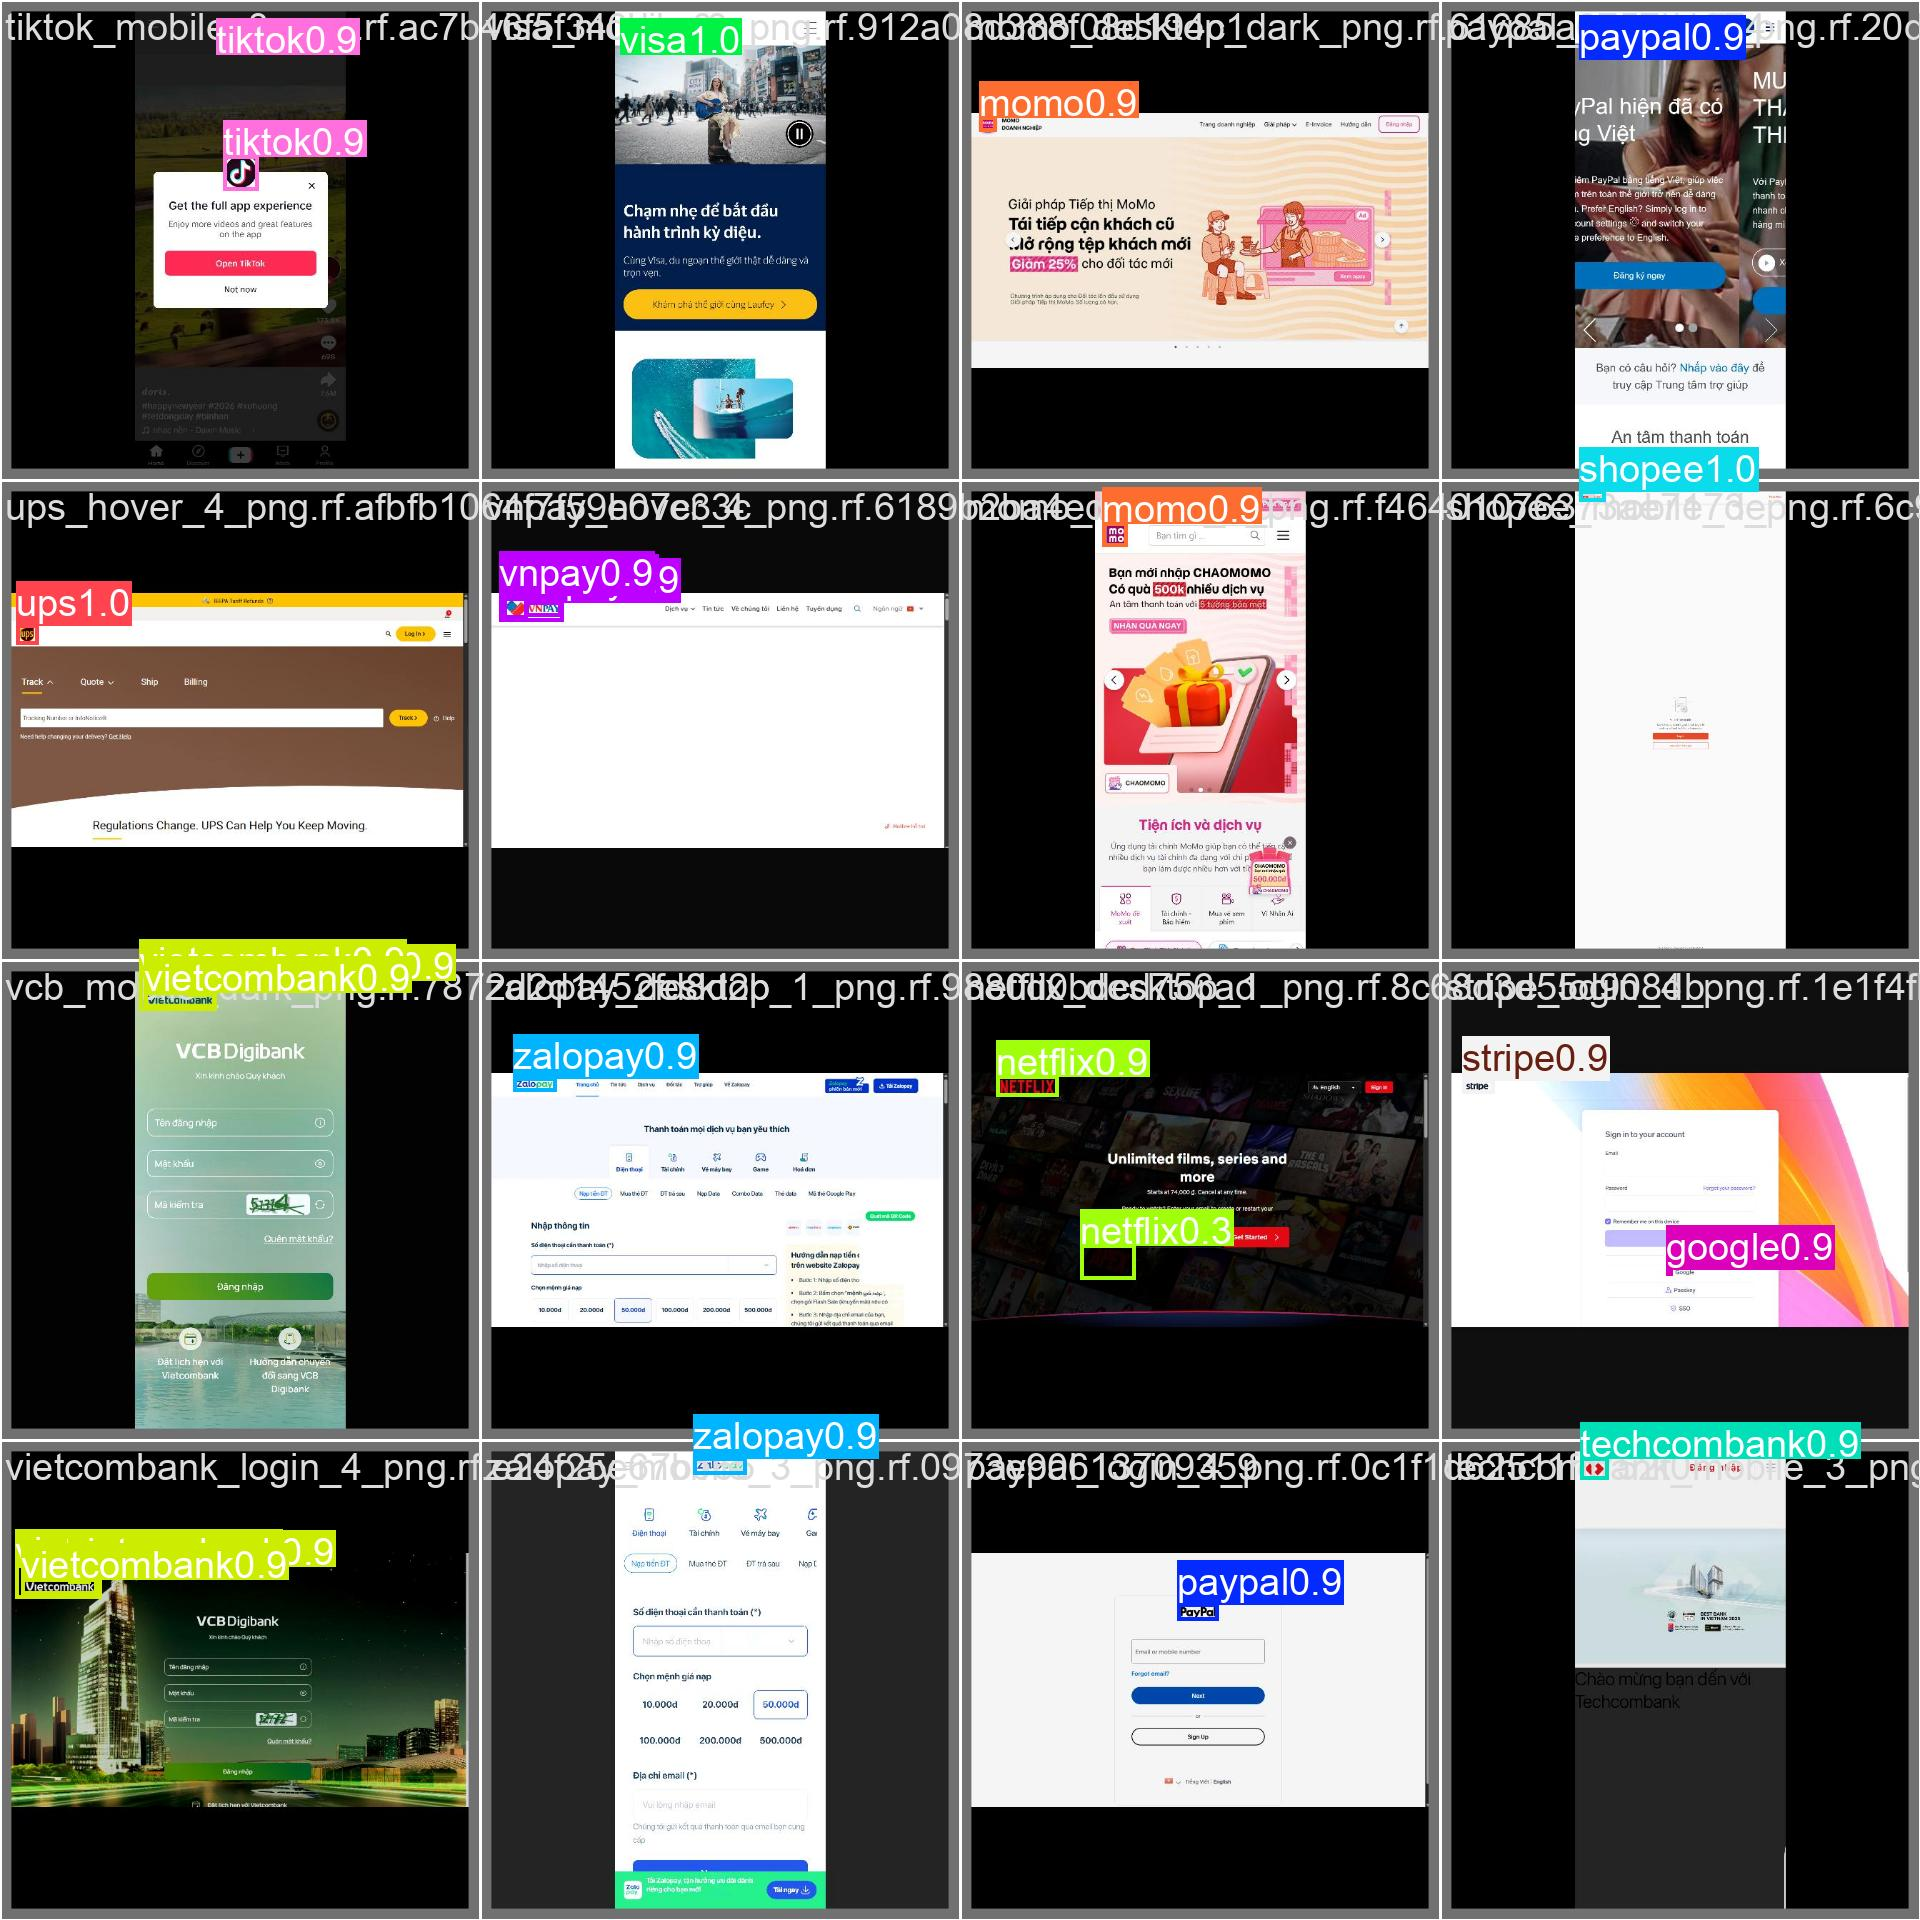


Predictions: val_batch1_pred.jpg


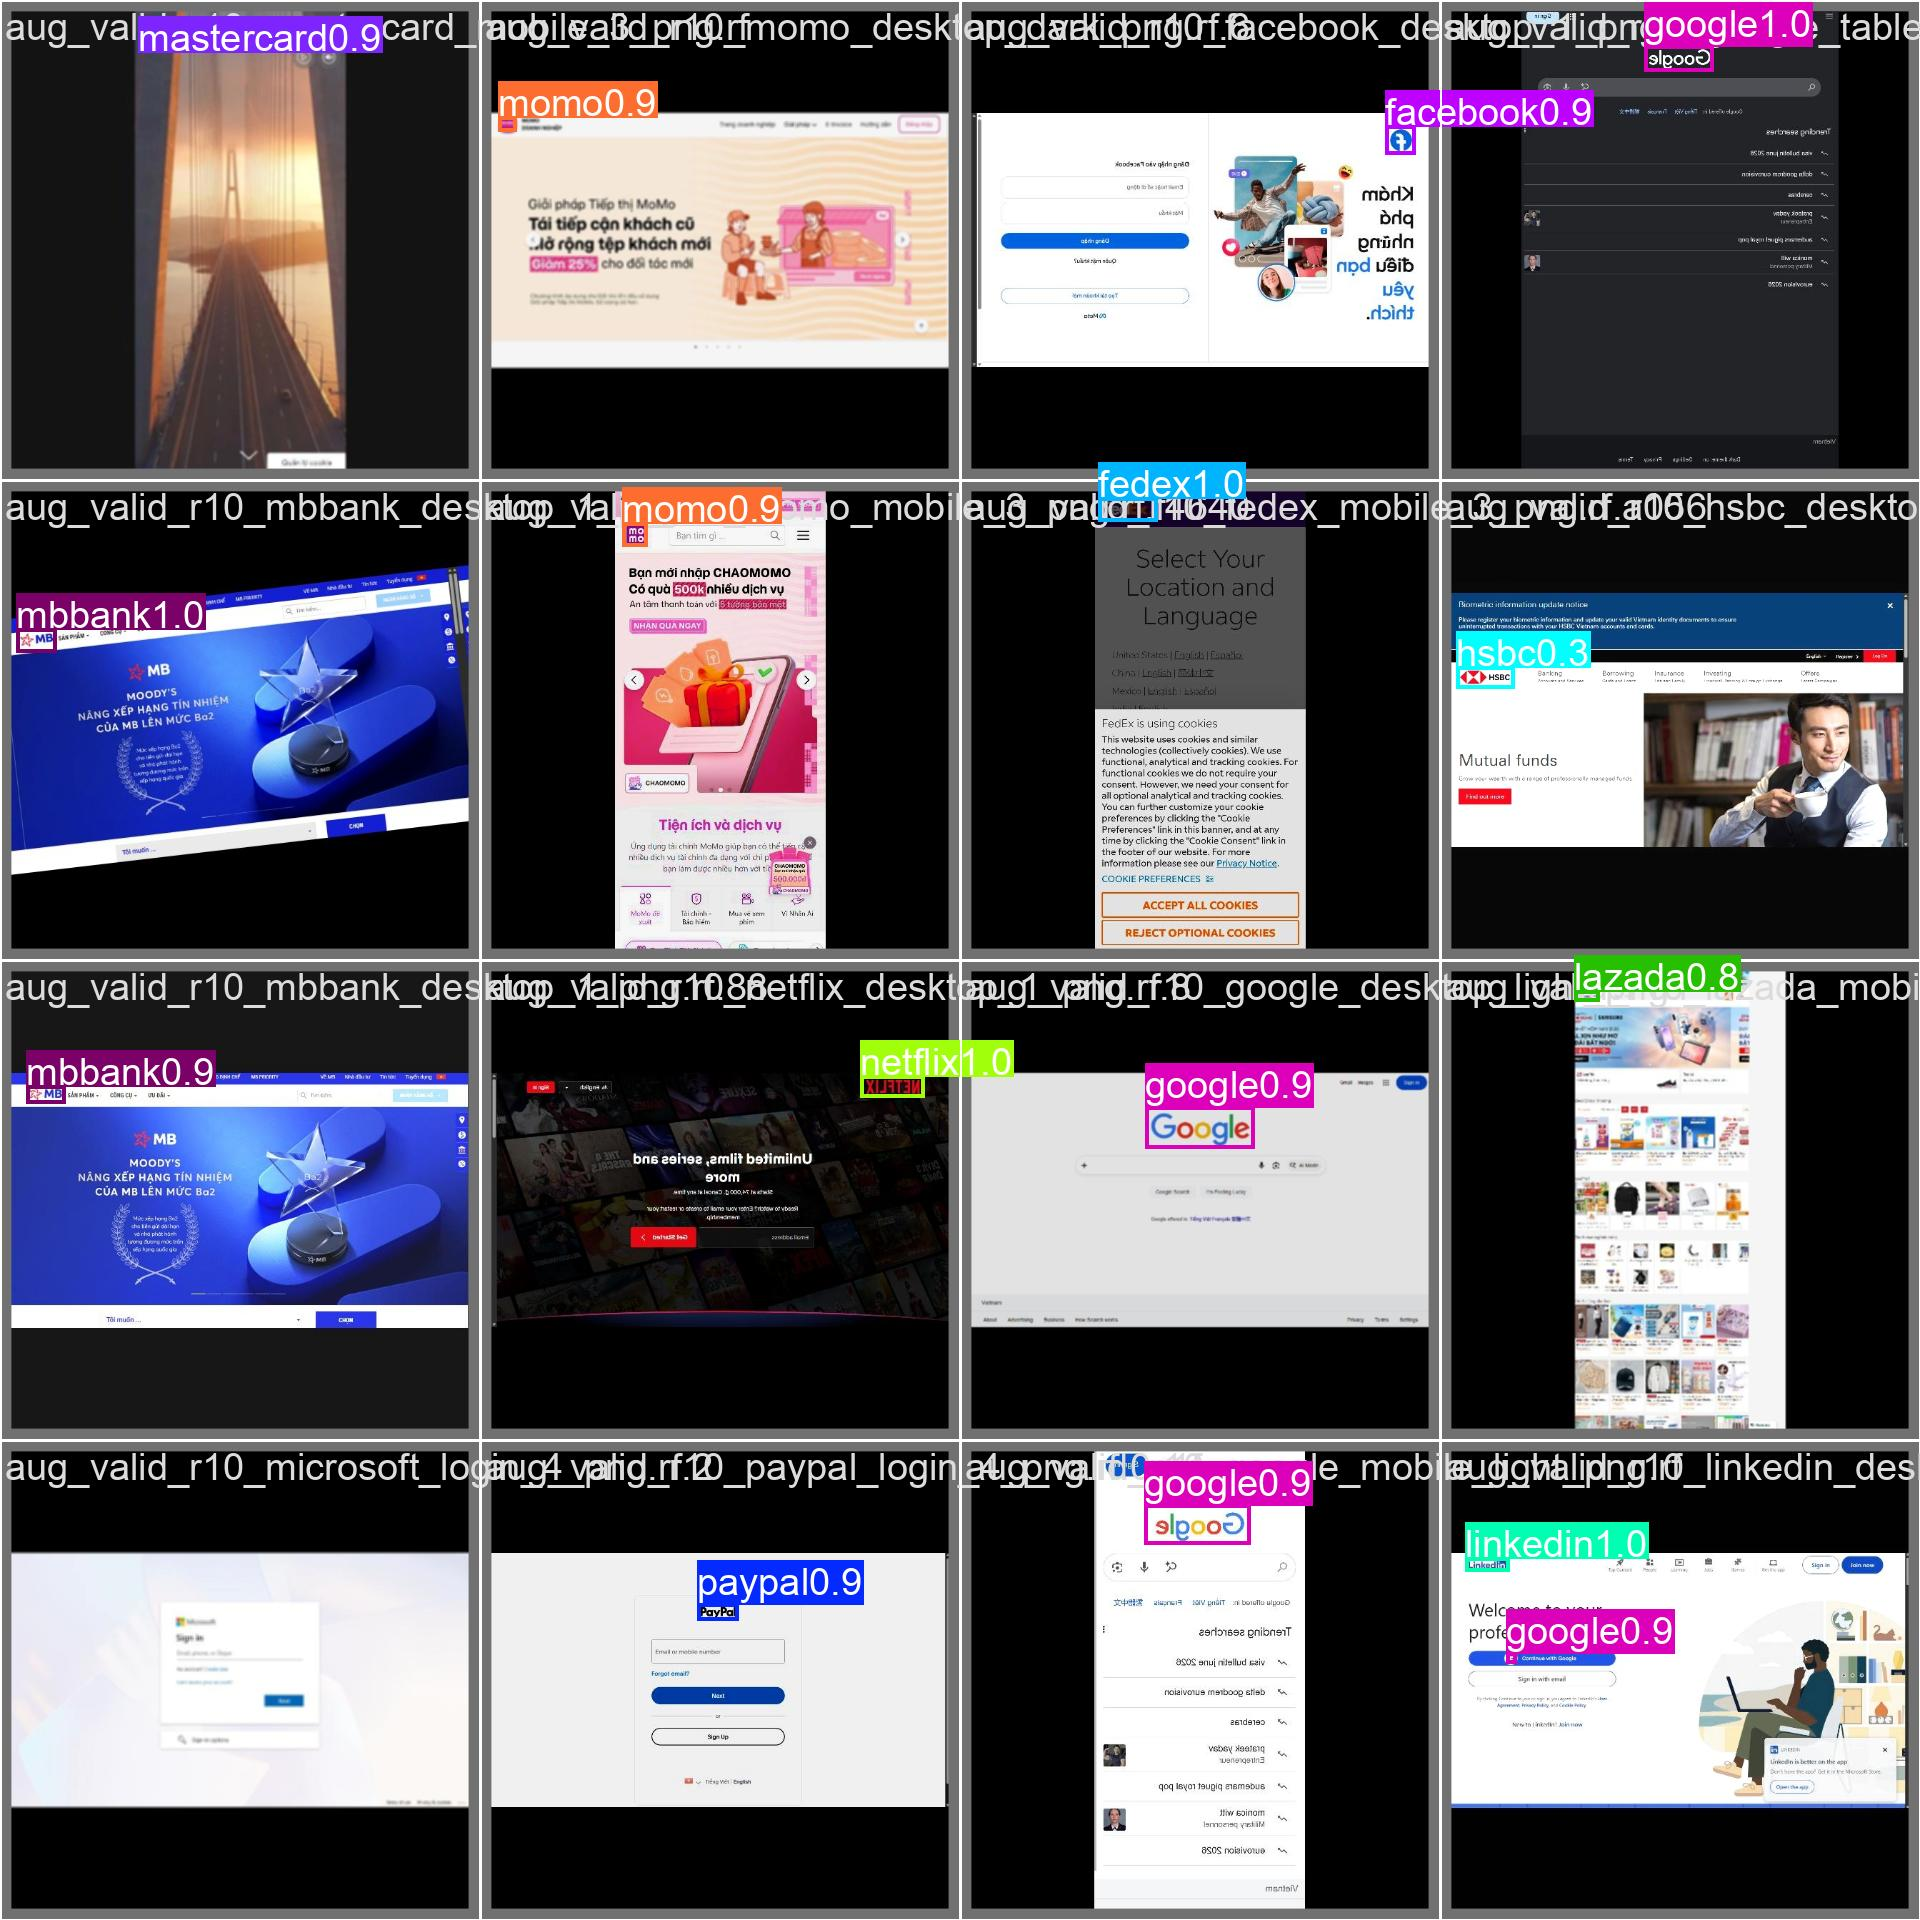


Predictions: val_batch2_pred.jpg


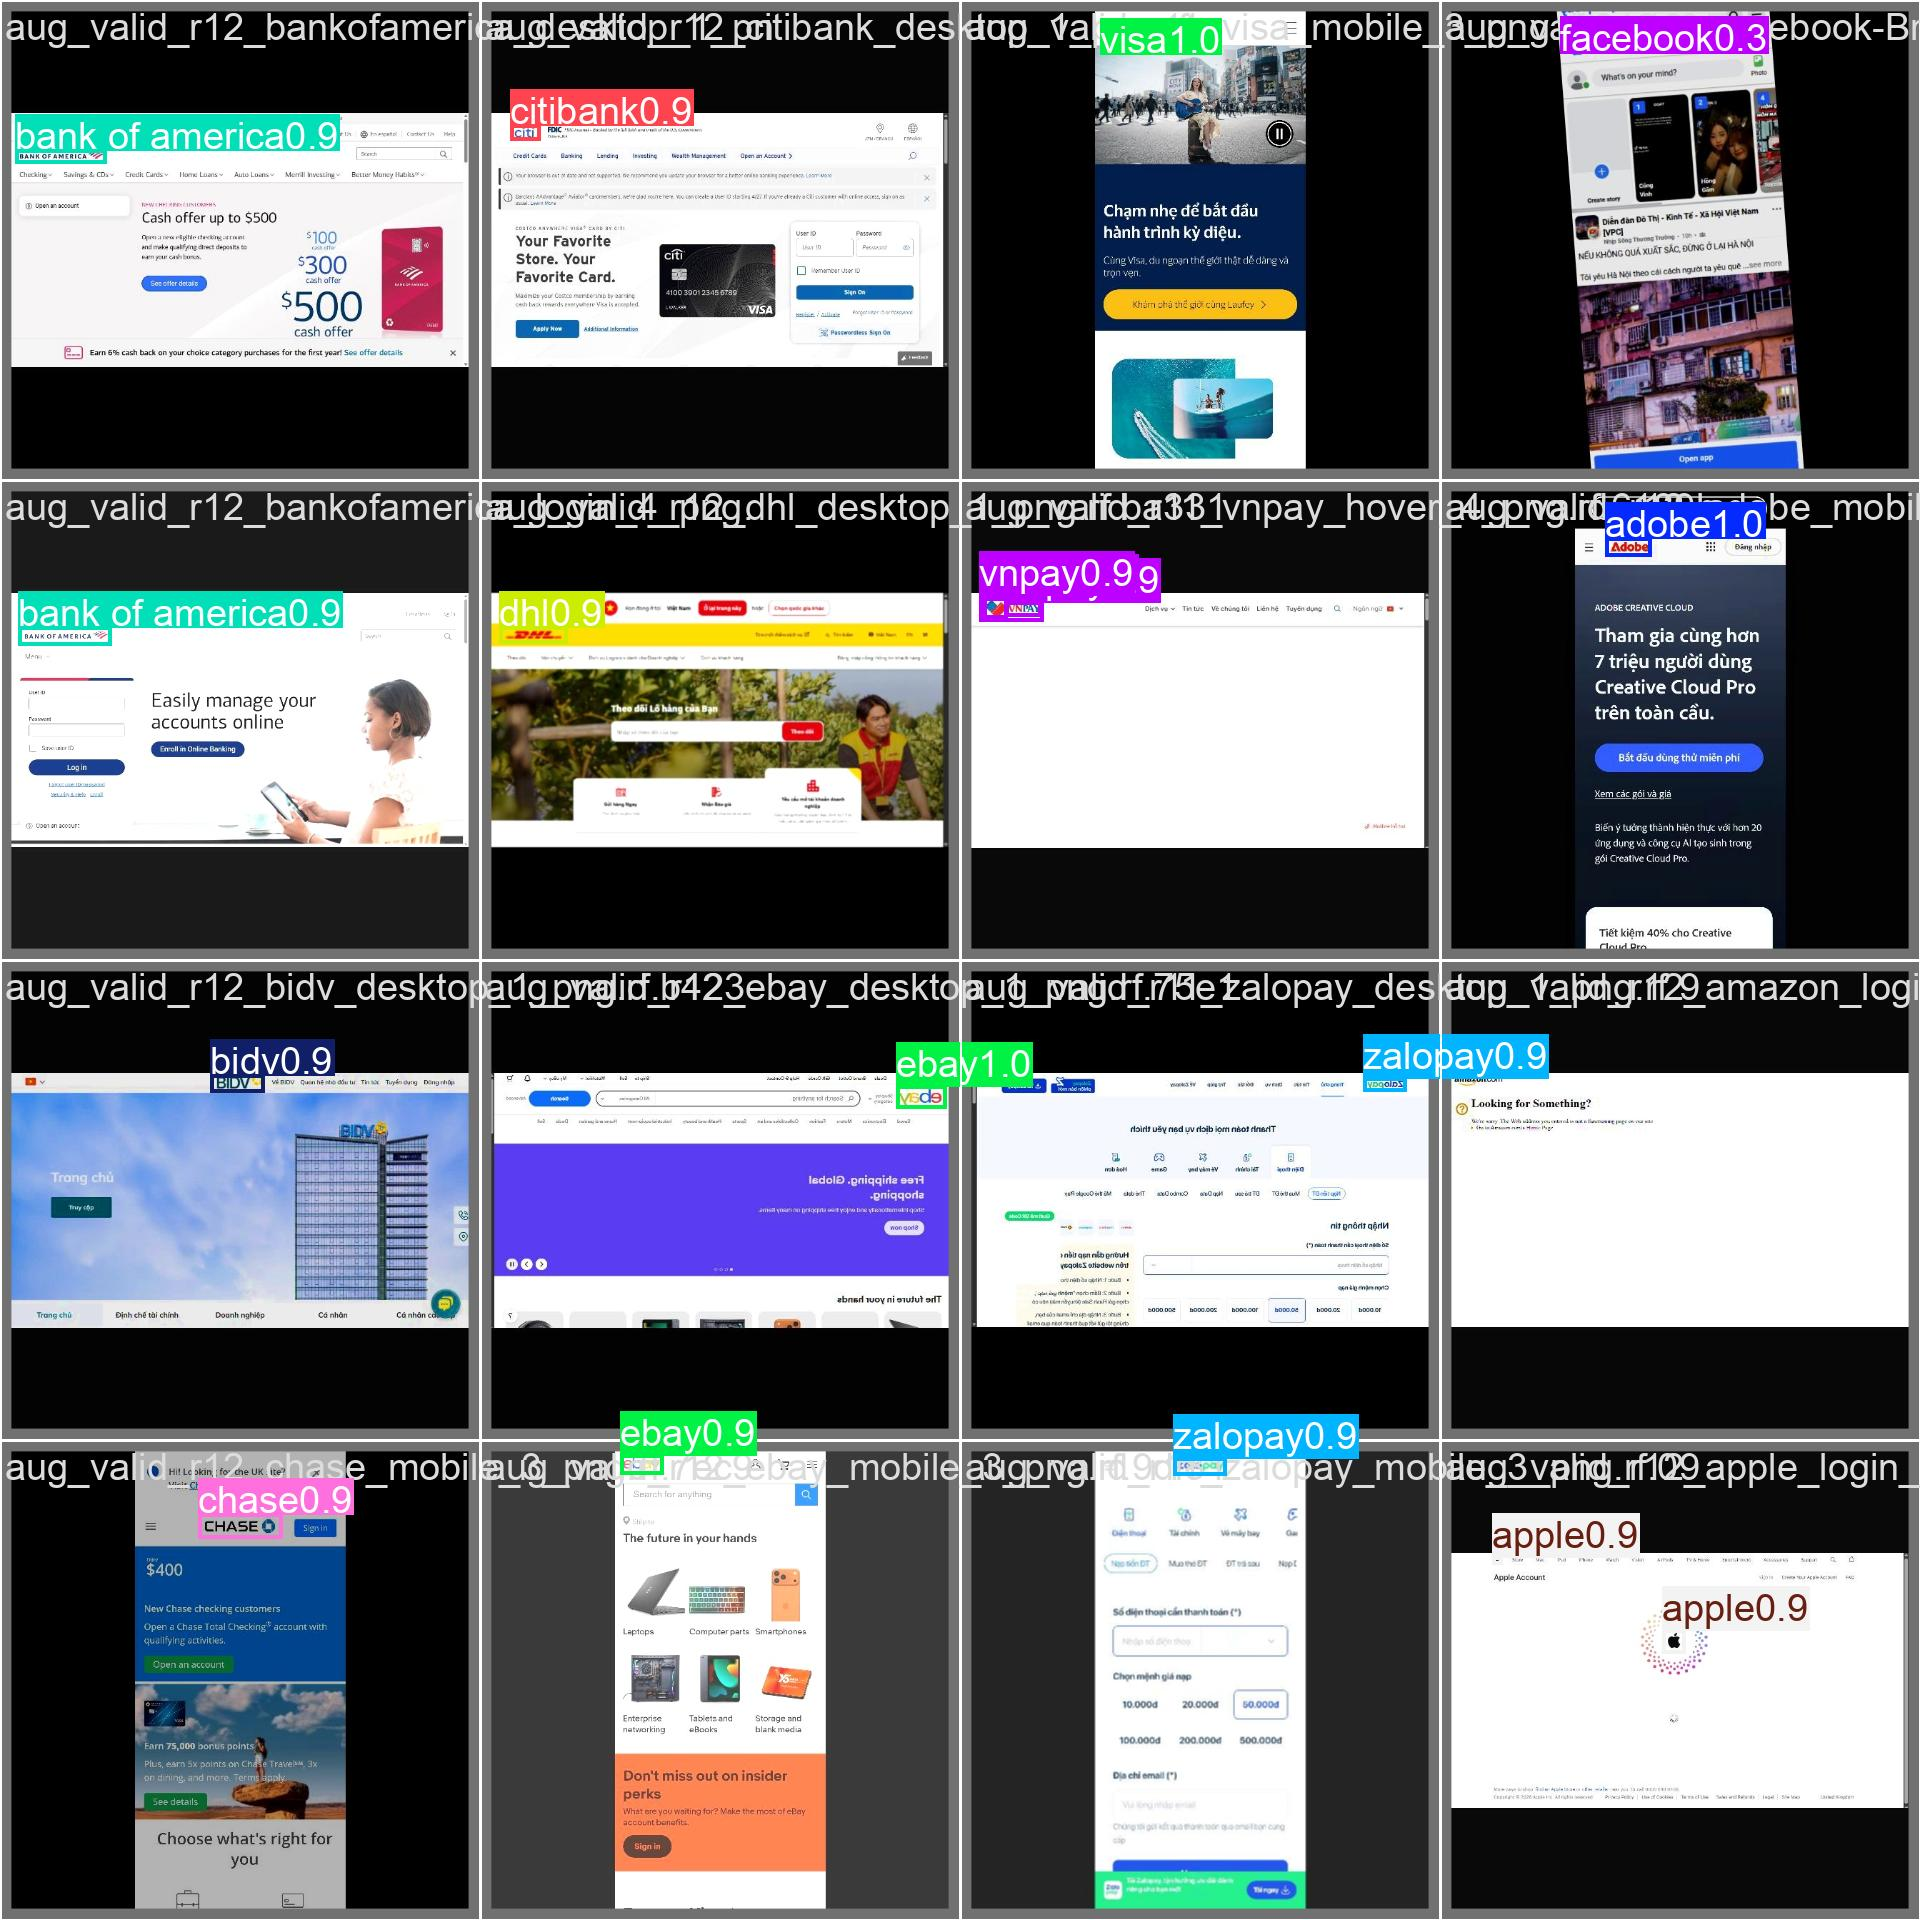


Ground Truth: val_batch0_labels.jpg


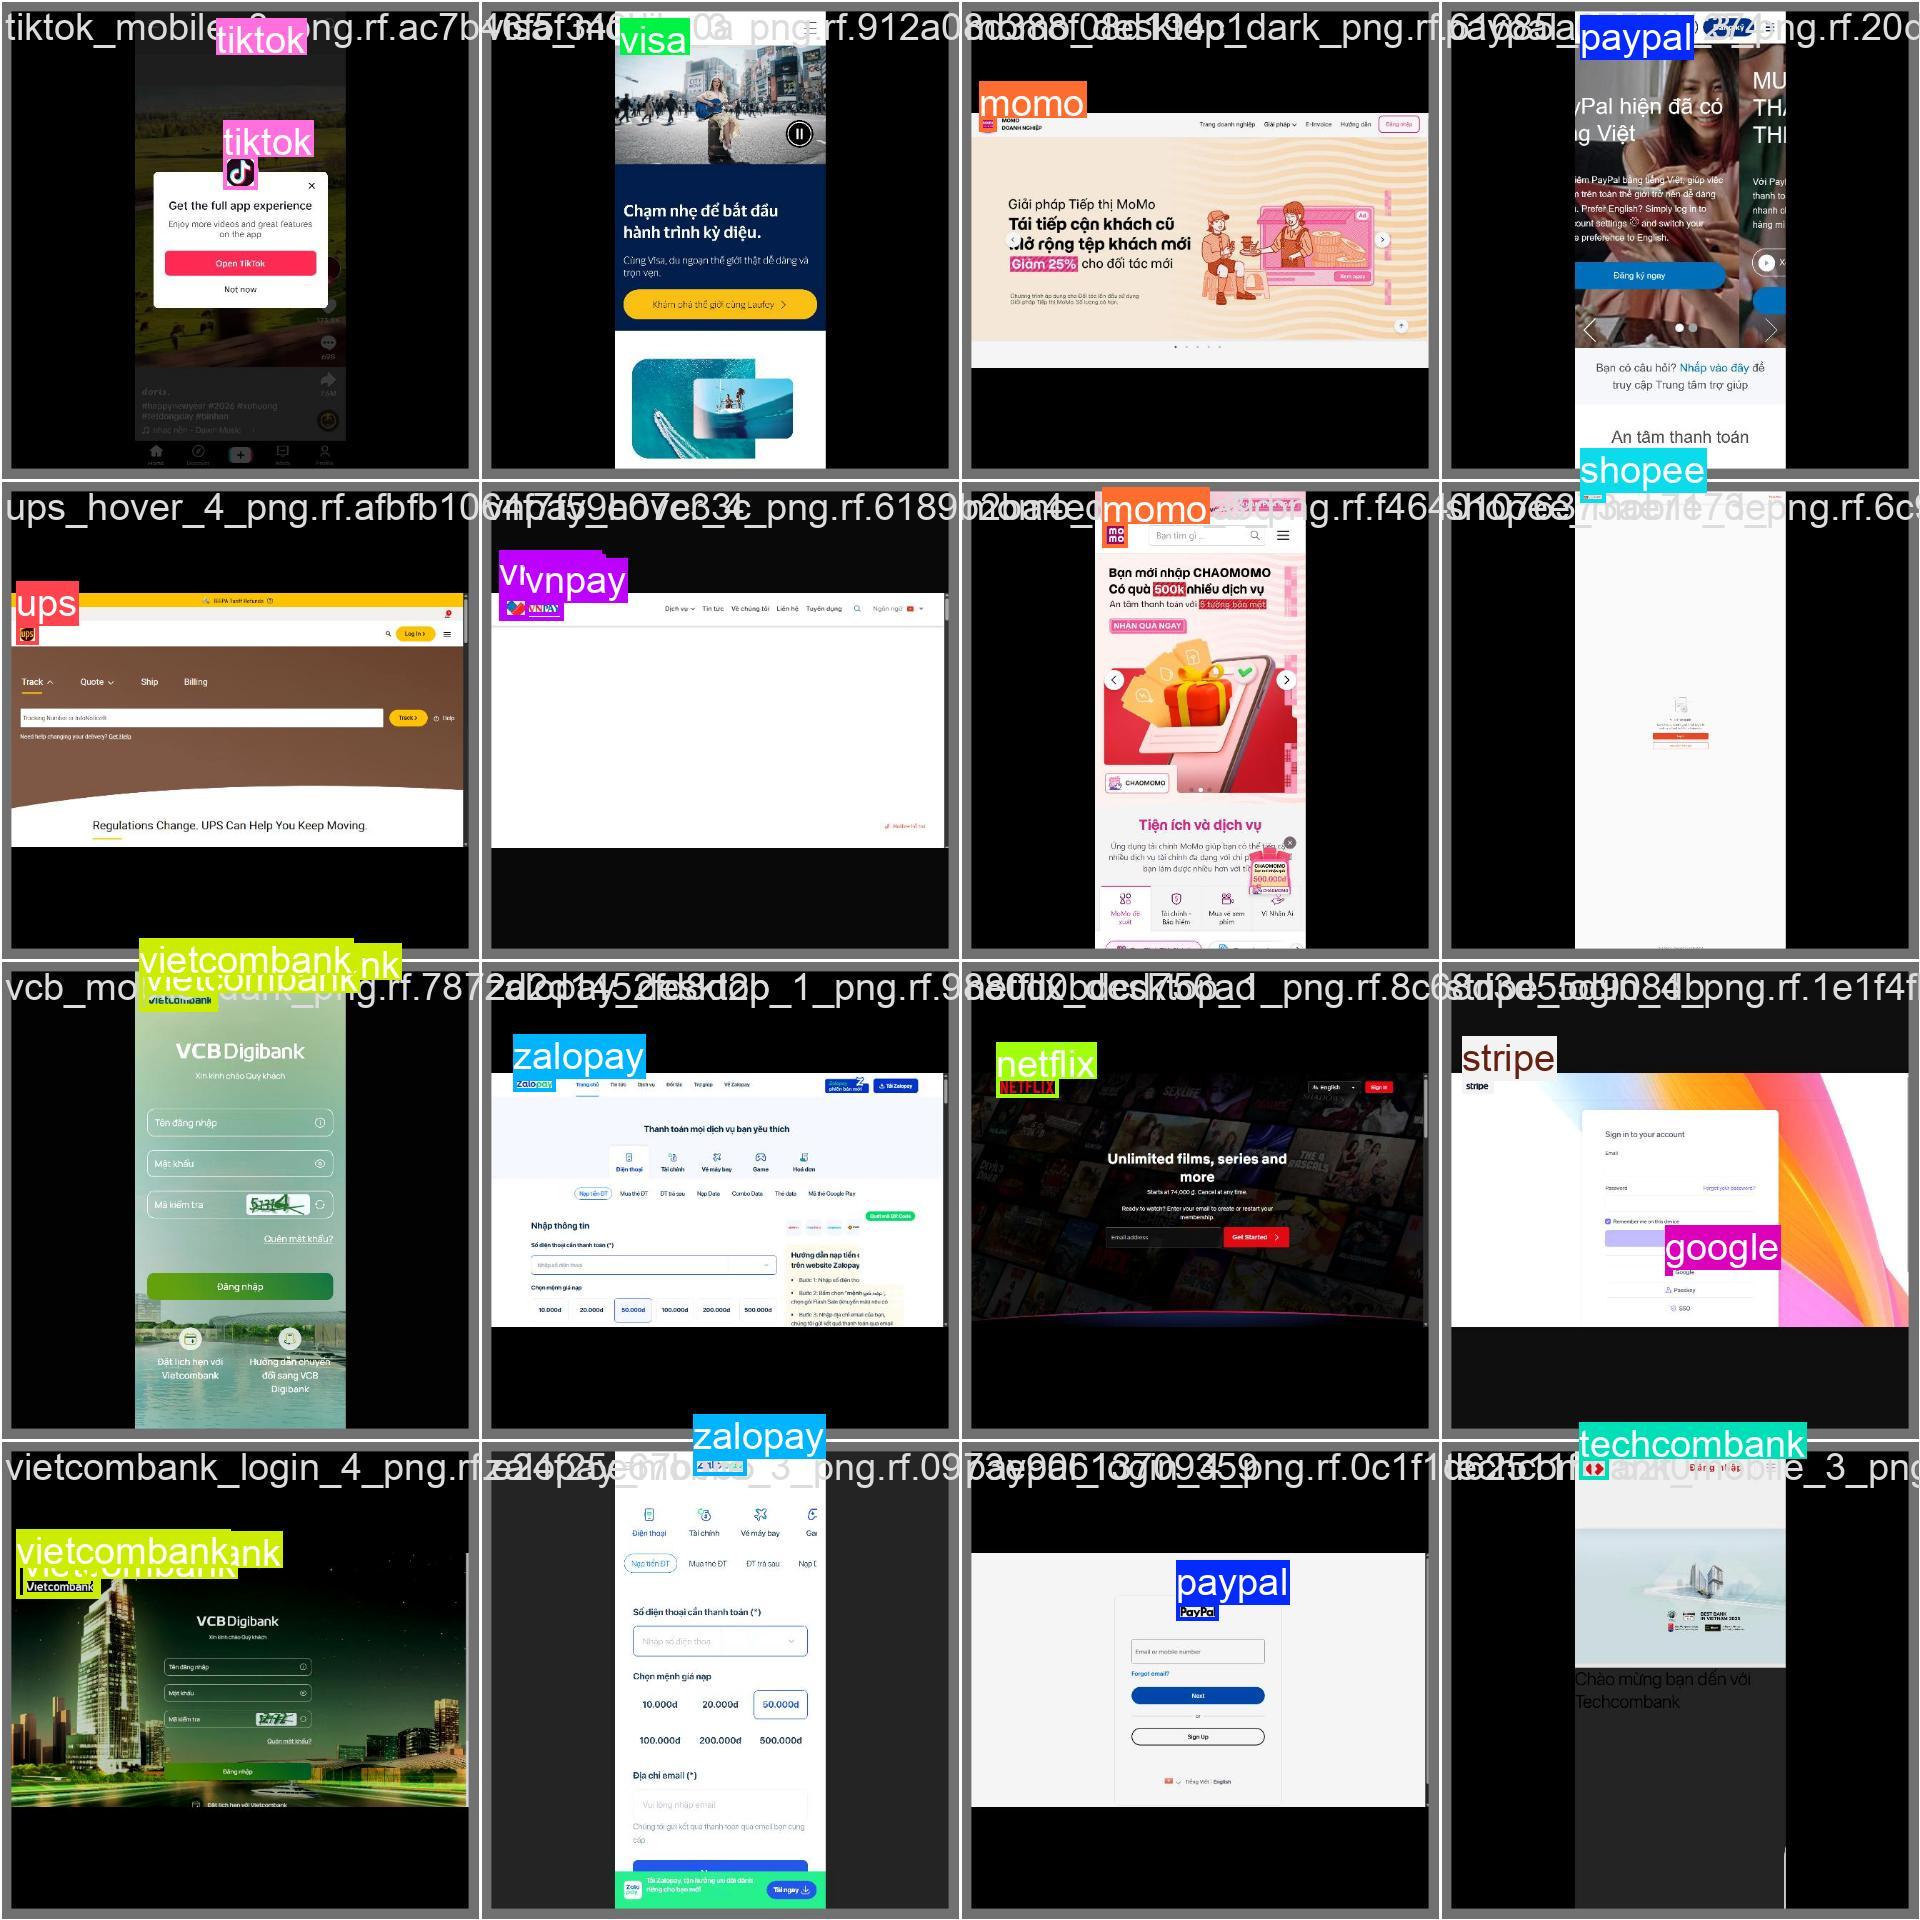


Ground Truth: val_batch1_labels.jpg


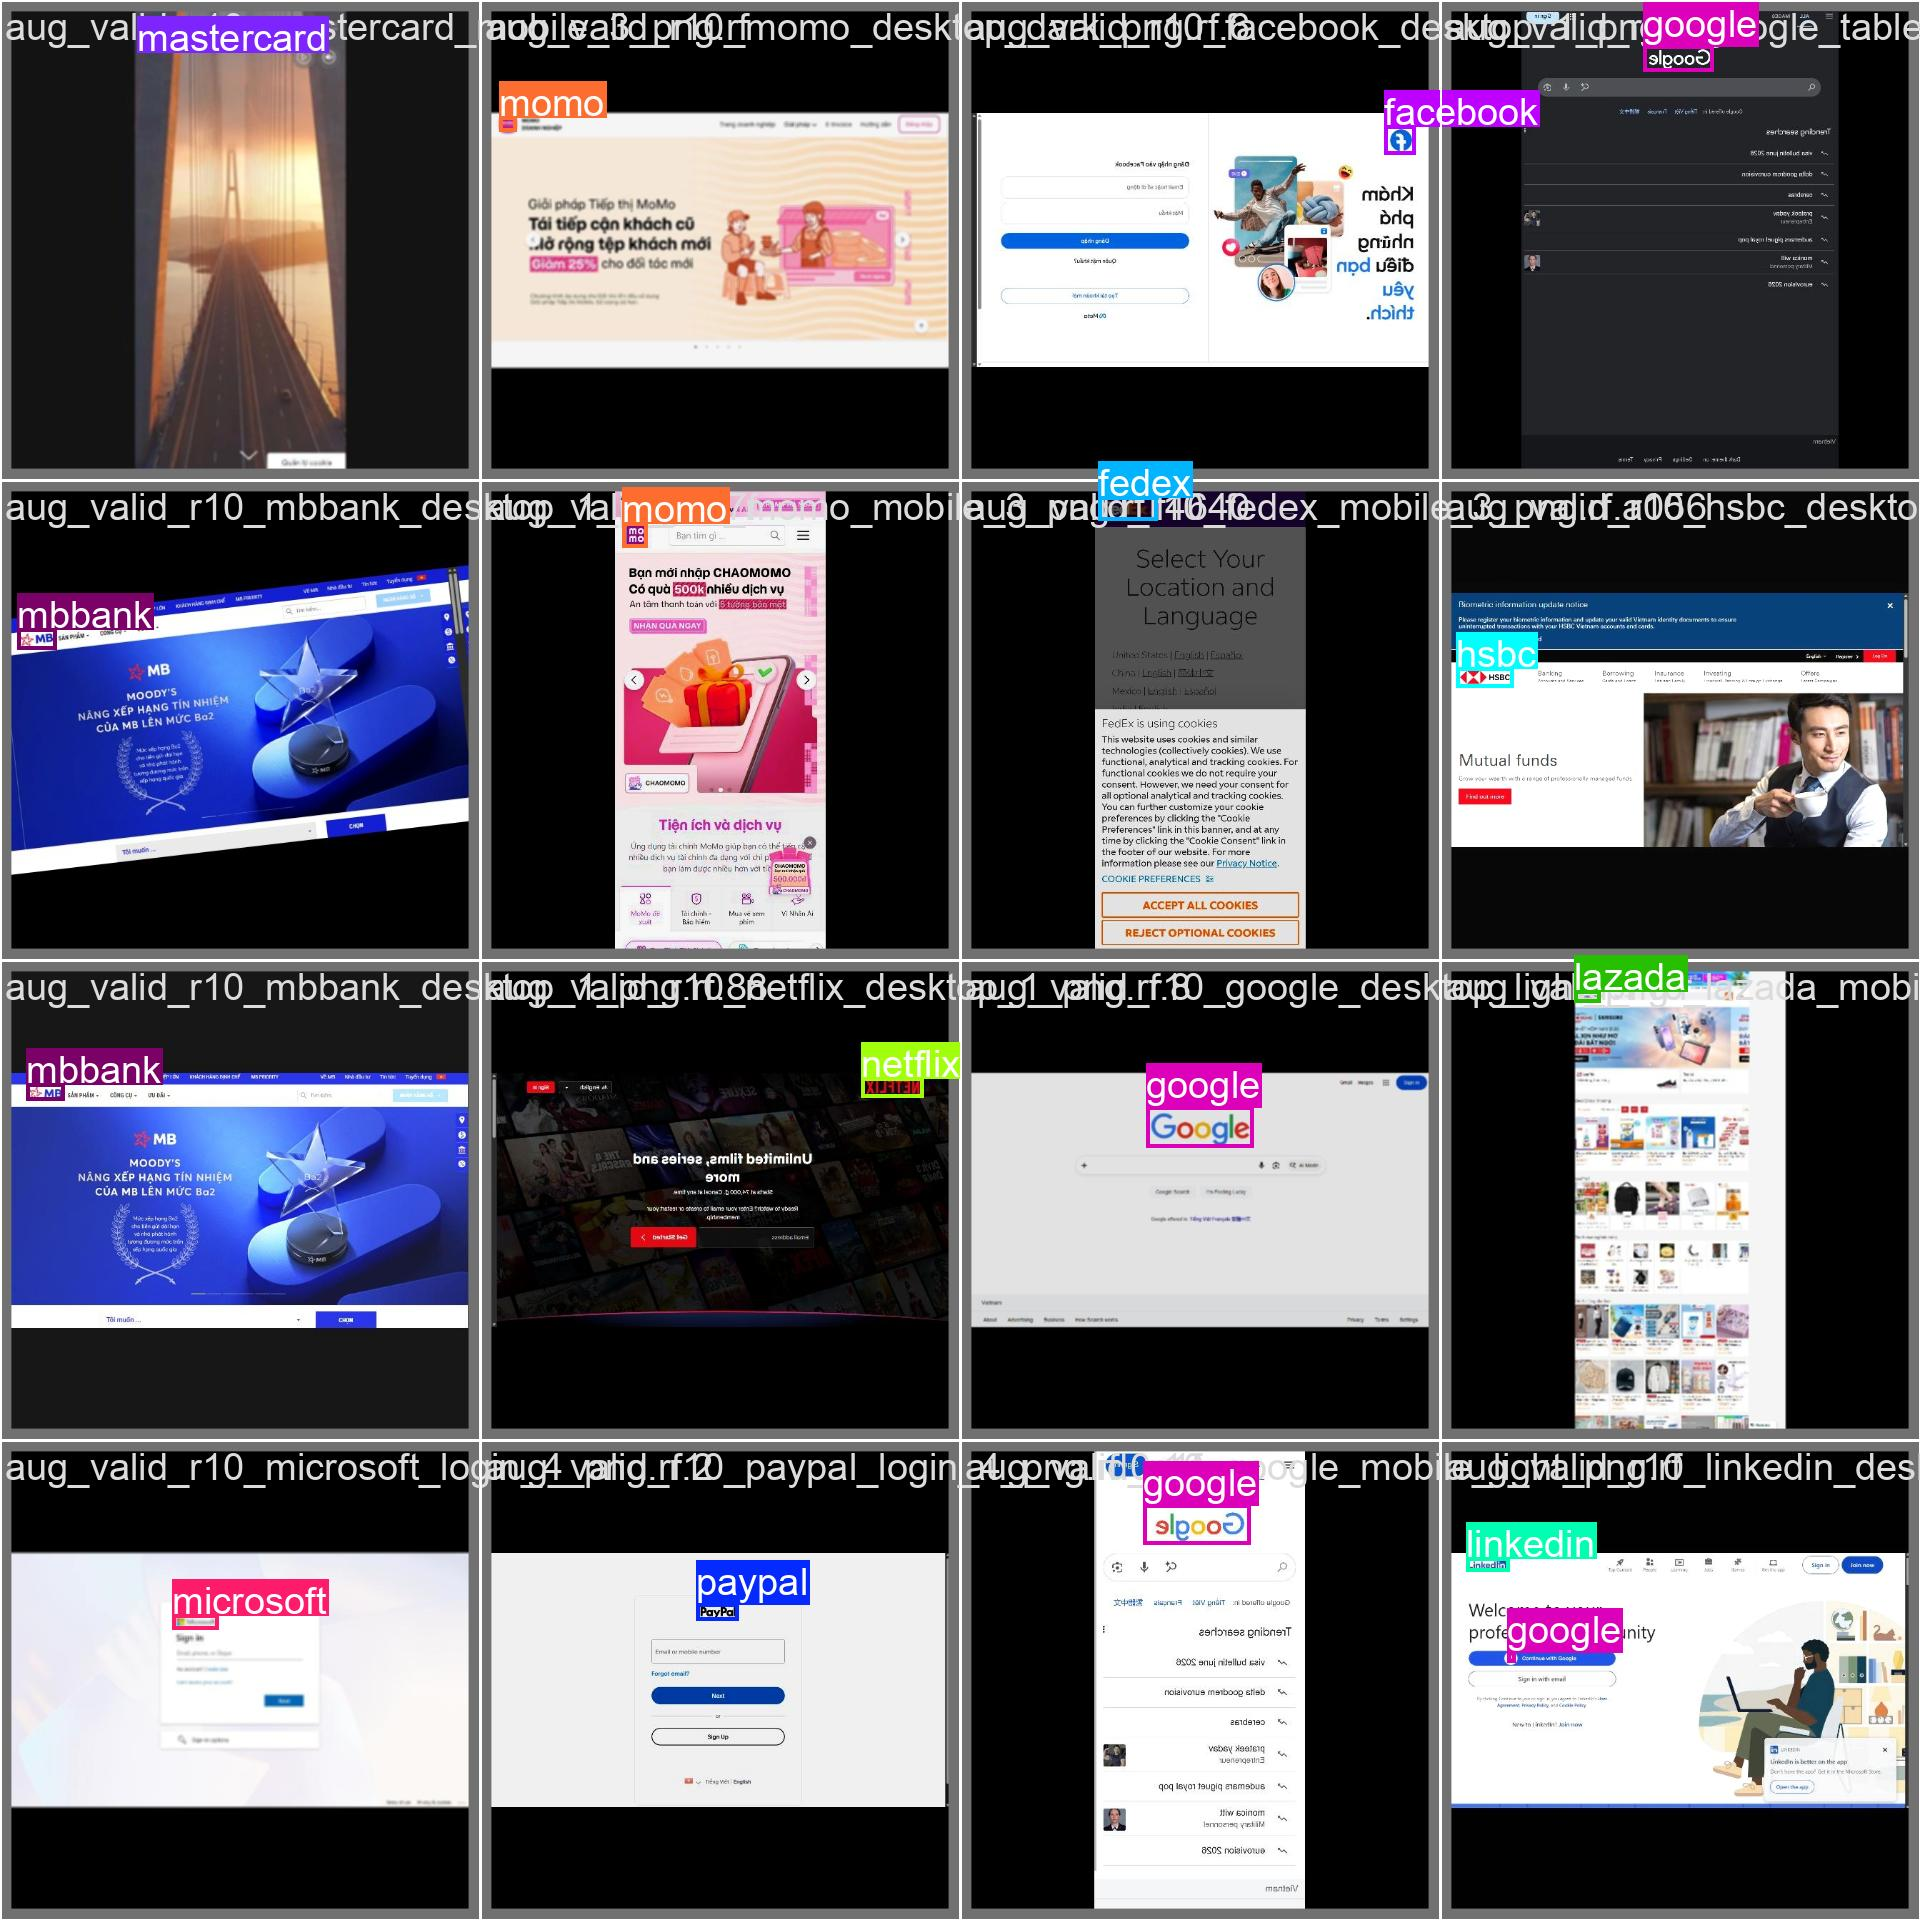


Ground Truth: val_batch2_labels.jpg


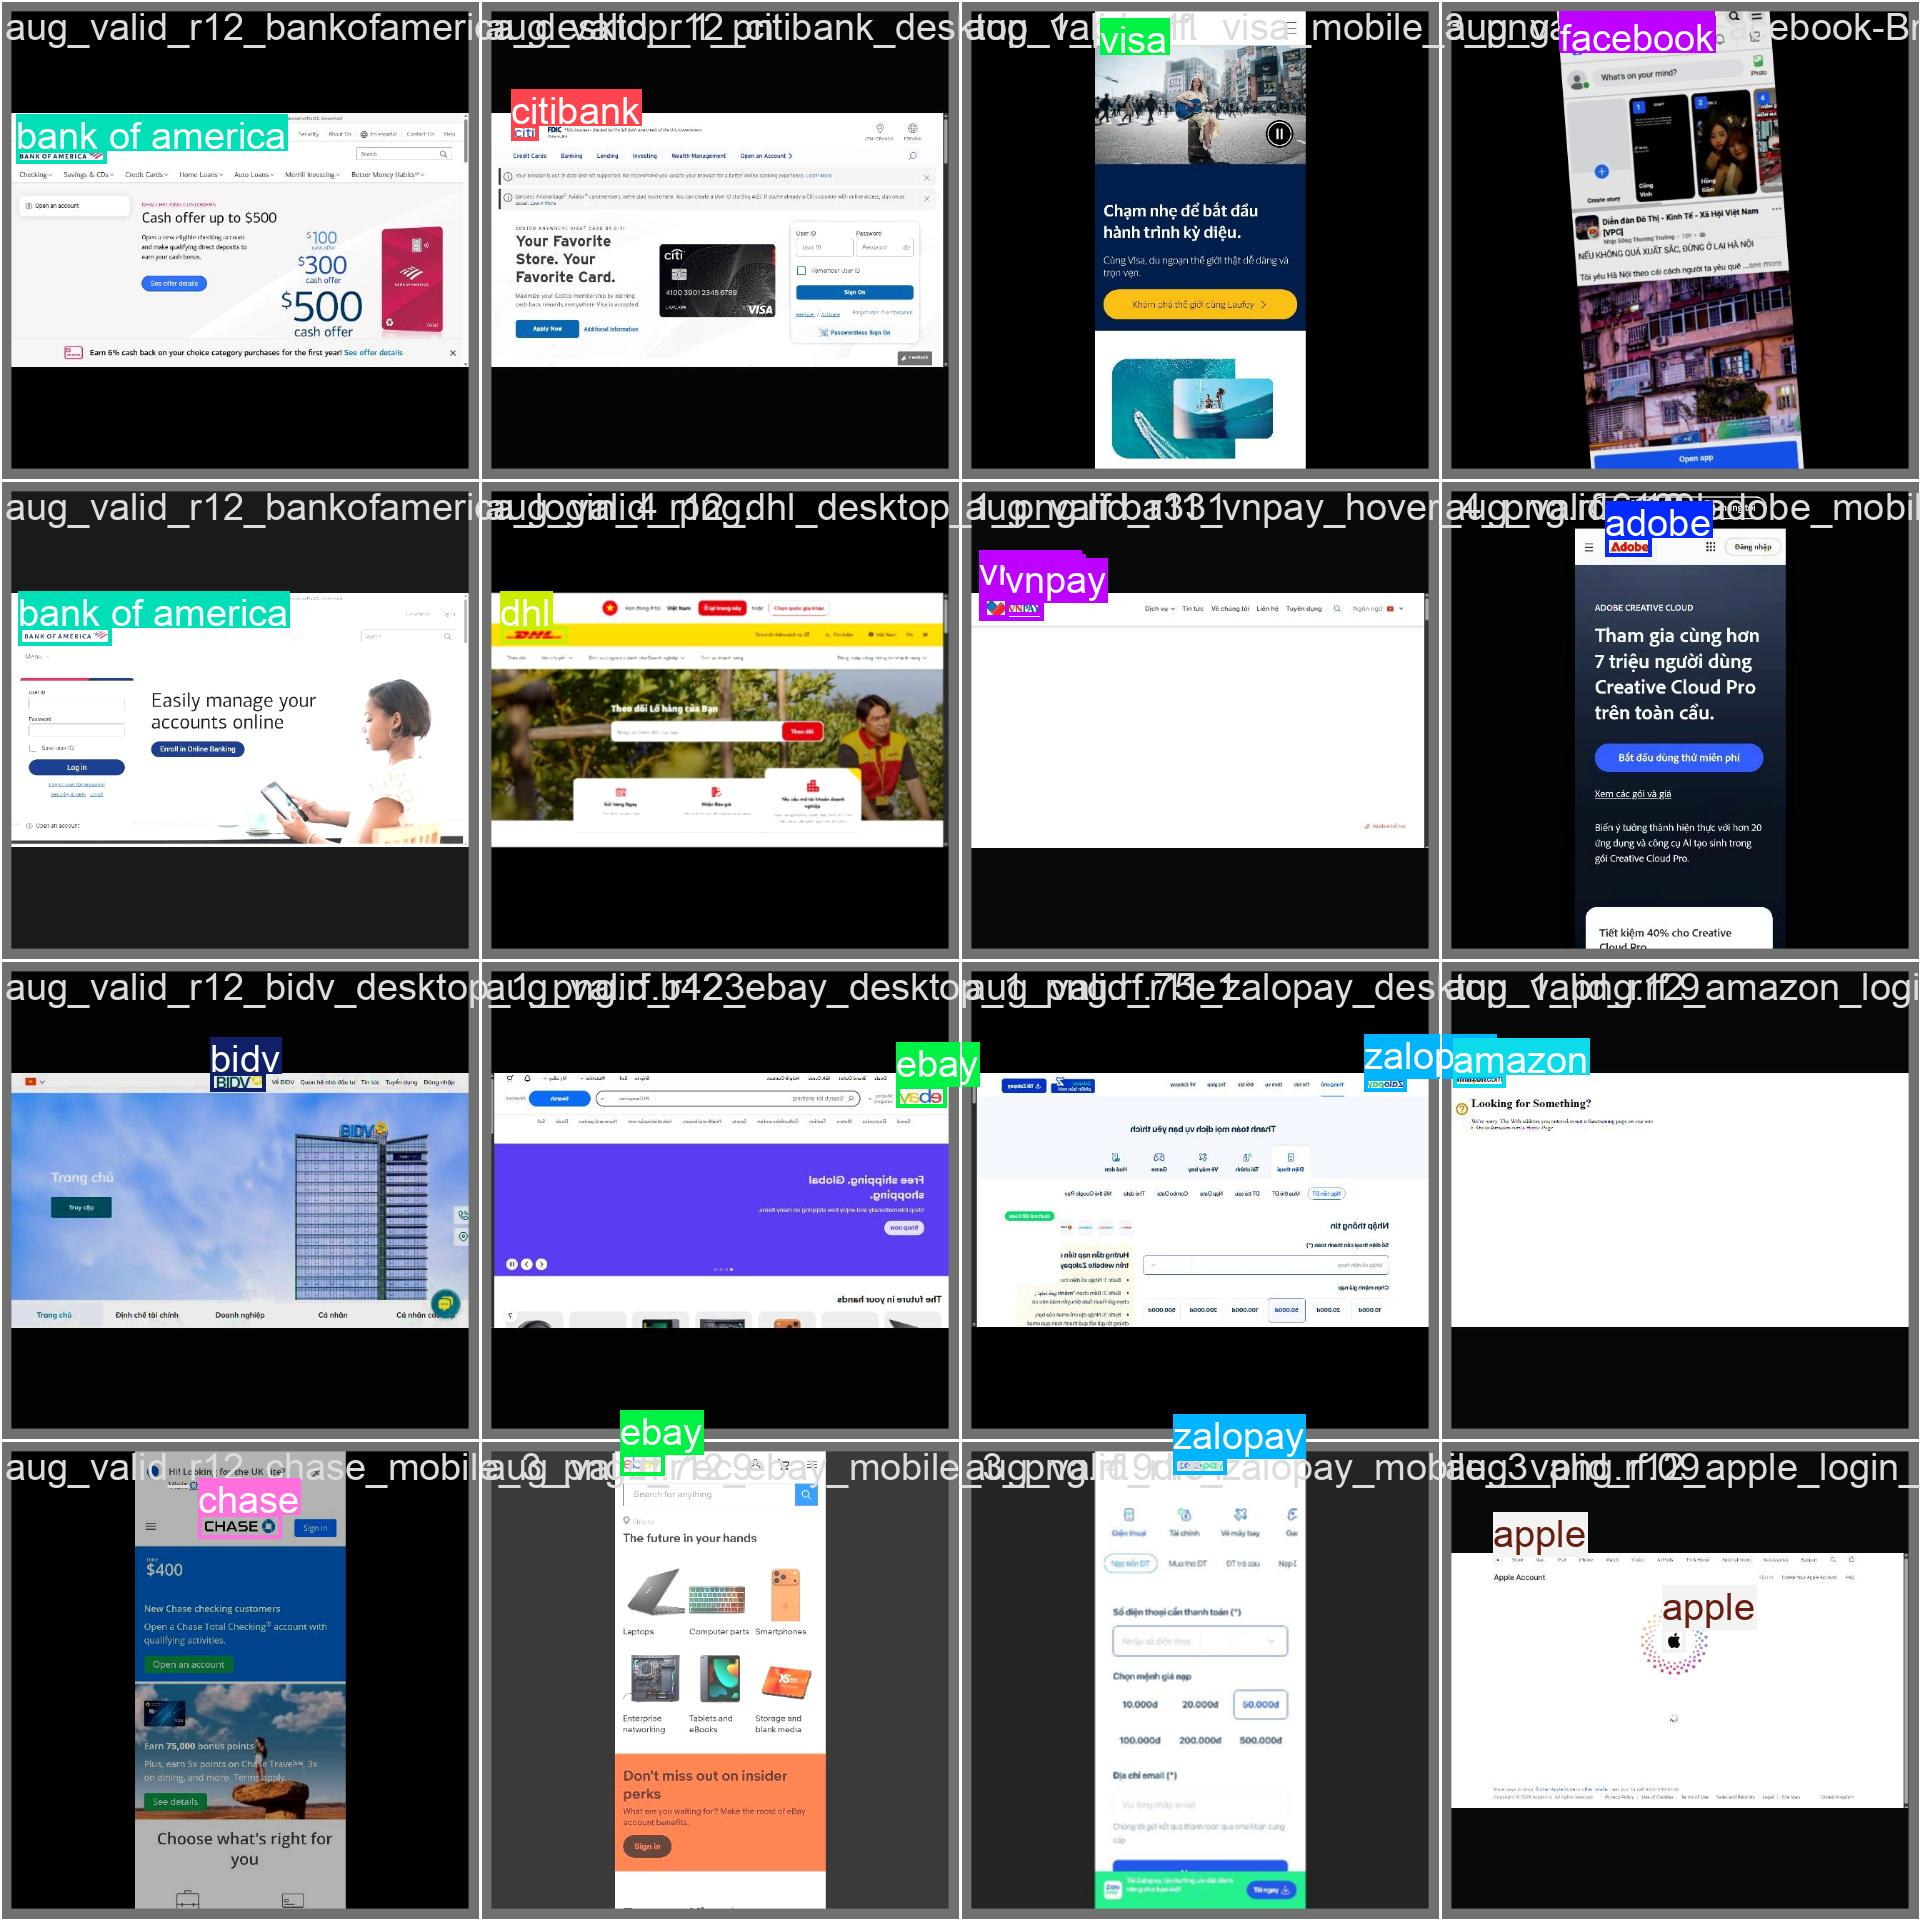

In [16]:
# 5.2 Display Validation Predictions (Sample Batches)
import glob
from IPython.display import Image, display

print("=" * 60)
print("🖼️ SAMPLE VALIDATION PREDICTIONS")
print("=" * 60)

# Find prediction batch images
pred_patterns = [
    os.path.join(TRAIN_DIR, "val_batch*_pred.jpg"),
    os.path.join(TRAIN_DIR, "val_batch*_labels.jpg"),
]

for pattern in pred_patterns:
    matches = sorted(glob.glob(pattern))
    for img_path in matches[:3]:  # Show max 3 per type
        fname = os.path.basename(img_path)
        label = "Predictions" if "pred" in fname else "Ground Truth"
        print(f"\n{label}: {fname}")
        display(Image(filename=img_path, width=800))

---
## 6. Model Inference Test

>>> Running inference on sample validation images...

🔍 aug_valid_r4_paypal_mobile_3_png.rf.20dc032094211e1526b48dbf9cb6bddd.jpg — 1 logo(s) detected
   └─ paypal: 94.32% confidence


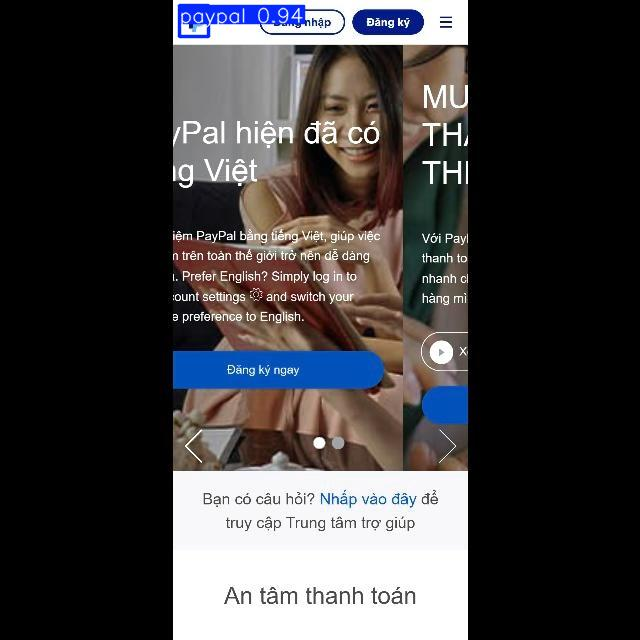


🔍 aug_valid_r9_vietcombank_login_4_png.rf.e24f25e67b165ec64dbf871a203475b3.jpg — 3 logo(s) detected
   └─ vietcombank: 92.24% confidence
   └─ vietcombank: 92.22% confidence
   └─ vietcombank: 87.40% confidence


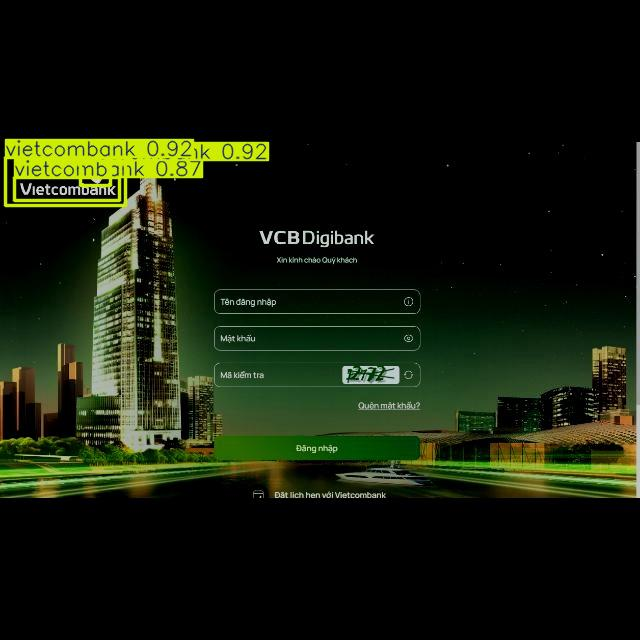


🔍 aug_valid_r14_bankofamerica_desktop_1_png.rf.079bc09ba50d3efc7fd6a4be60305192.jpg — 1 logo(s) detected
   └─ bank of america: 93.91% confidence


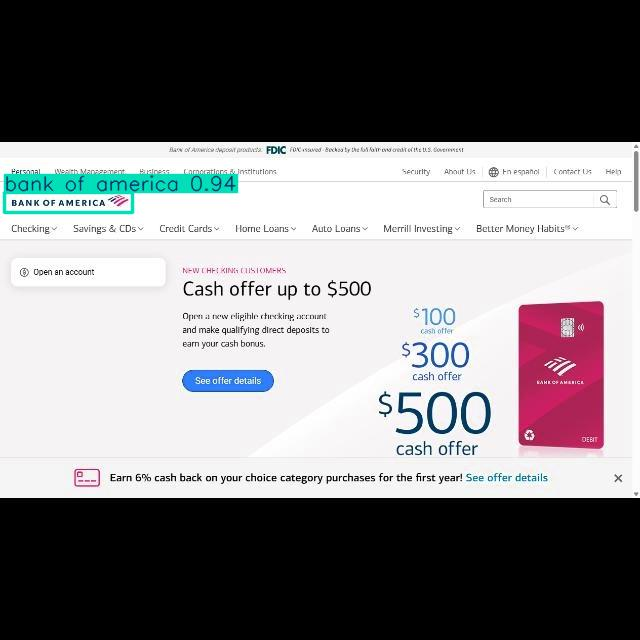


🔍 aug_valid_r18_zalopay_mobile_3_png.rf.0973e906137093592b8b64d41d8de997.jpg — 1 logo(s) detected
   └─ zalopay: 94.48% confidence


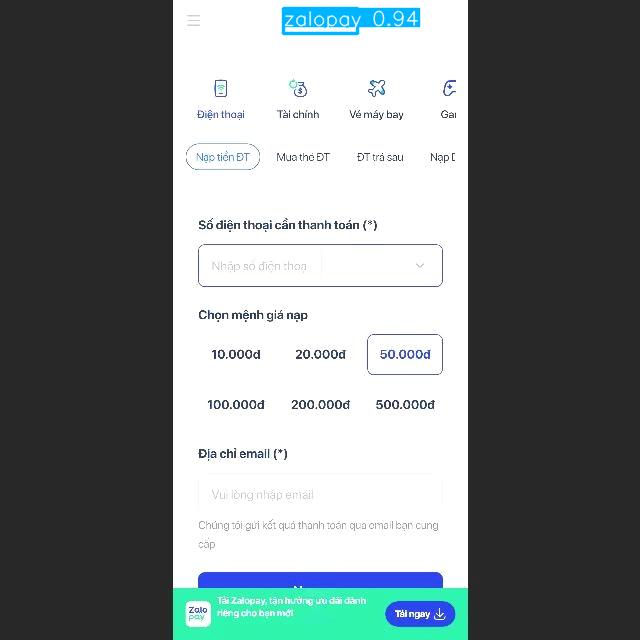

In [17]:
# 6.1 Test on sample images from the validation set
import glob
import random
from IPython.display import Image, display

val_images_dir = os.path.join(dataset.location, "valid", "images")
val_images = glob.glob(os.path.join(val_images_dir, "*.*"))

if val_images:
    # Pick 4 random validation images
    sample_images = random.sample(val_images, min(4, len(val_images)))

    print(">>> Running inference on sample validation images...\n")
    for img_path in sample_images:
        results = best_model(img_path, verbose=False)

        # Save annotated result
        annotated = results[0].plot()
        save_path = f"/kaggle/working/test_{os.path.basename(img_path)}"
        from PIL import Image as PILImage
        PILImage.fromarray(annotated[..., ::-1]).save(save_path)

        # Print detections
        n_detections = len(results[0].boxes)
        print(f"🔍 {os.path.basename(img_path)} — {n_detections} logo(s) detected")
        for box in results[0].boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            cls_name = best_model.names[cls_id]
            print(f"   └─ {cls_name}: {conf:.2%} confidence")

        display(Image(filename=save_path, width=500))
        print()
else:
    print("⚠️ No validation images found for testing.")

---
## 7. Export & Save Model

In [18]:
# 7.1 Model Size & Speed Benchmark
import os

best_pt = os.path.join(TRAIN_DIR, "weights", "best.pt")
last_pt = os.path.join(TRAIN_DIR, "weights", "last.pt")

print("📦 Model File Sizes:")
if os.path.exists(best_pt):
    size_mb = os.path.getsize(best_pt) / (1024 * 1024)
    print(f"   best.pt : {size_mb:.2f} MB")
if os.path.exists(last_pt):
    size_mb = os.path.getsize(last_pt) / (1024 * 1024)
    print(f"   last.pt : {size_mb:.2f} MB")

# Run speed benchmark
print("\n⏱️ Inference Speed Benchmark (T4 GPU):")
speed = best_model.benchmark(imgsz=IMG_SIZE, verbose=False)
print(speed)

Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.2/8062.4 GB disk)

Benchmarks complete for runs/detect/yolo26_phishing_project/yolo26_logo_run/weights/best.pt on coco8.yaml at imgsz=640 (0.39s)
Benchmarks legend:  - ✅ Success  - ❎ Export passed but validation failed  - ❌️ Export failed
+--------------------------------------------------------------------------------------------------------+
|      Format                  Status❔   Size (MB)   metrics/mAP50-95(B)   Inference time (ms/im)   FPS |
+========================================================================================================+
| 1    PyTorch                 ❌         5.2         -                     -                        -   |
| 2    TorchScript             ❌         0.0         -                     -                        -   |
| 3    ONNX                    ❌         0.0         -                     -                        -   |
| 4    OpenVINO                ❌         0.0         -                     -   

In [19]:
# 7.2 Save Best Model to Kaggle Output (downloadable)
import shutil

# Source: best model from training
best_model_path = os.path.join(TRAIN_DIR, 'weights', 'best.pt')

# Destination: Kaggle output directory (auto-downloadable after run)
kaggle_save_dir = '/kaggle/working/model_output'
os.makedirs(kaggle_save_dir, exist_ok=True)
kaggle_save_path = os.path.join(kaggle_save_dir, 'yolo_logo_detector.pt')

print(f'>>> Source : {best_model_path}')
print(f'>>> Target : {kaggle_save_path}')

if os.path.exists(best_model_path):
    shutil.copy(best_model_path, kaggle_save_path)
    saved_size = os.path.getsize(kaggle_save_path) / (1024 * 1024)
    print(f'\n🎉 SUCCESS! YOLO26 model saved ({saved_size:.2f} MB)')
    print(f'\n💡 Download from Kaggle:')
    print(f'   → Go to Output tab → model_output/ → yolo_logo_detector.pt')
    print(f'\n💡 To use in your API, copy this file to:')
    print(f'   src/models/saved_models/yolo_logo_detector.pt')

    # Also copy training plots for reference
    plots_dir = os.path.join(kaggle_save_dir, 'training_plots')
    os.makedirs(plots_dir, exist_ok=True)
    import glob
    for plot_file in glob.glob(os.path.join(TRAIN_DIR, '*.png')) + glob.glob(os.path.join(TRAIN_DIR, '*.jpg')):
        shutil.copy(plot_file, plots_dir)
    print(f'   📊 Training plots also saved to: {plots_dir}')
else:
    print(f'\n❌ ERROR: best.pt not found at {best_model_path}')
    print('   Check the training output directory above.')


>>> Source : runs/detect/yolo26_phishing_project/yolo26_logo_run/weights/best.pt
>>> Target : /kaggle/working/model_output/yolo_logo_detector.pt

🎉 SUCCESS! YOLO26 model saved (5.18 MB)

💡 Download from Kaggle:
   → Go to Output tab → model_output/ → yolo_logo_detector.pt

💡 To use in your API, copy this file to:
   src/models/saved_models/yolo_logo_detector.pt
   📊 Training plots also saved to: /kaggle/working/model_output/training_plots
